# 🔴 Deteksi Hate Speech Bahasa Indonesia
## Fuzzy Logic (Mamdani & Sugeno) + Deep Learning (LSTM) — Integrasi Hibrida

**Dataset:** Indonesian Hate Speech Detection Dataset (ID-Hate-Speech-and-Abusive-Language-Detection)  
**Sumber:** https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection  
**Jumlah Data:** 13.169 baris × 13 variabel

---
### Arsitektur Sistem
```
Input Text
    │
    ▼
[Preprocessing + Feature Extraction]
    │                  │
    ▼                  ▼
[LSTM Deep Learning]  [Fuzzy Feature Engineering]
    │                  │
    └──────┬───────────┘
           ▼
   [Fuzzy Mamdani / Sugeno]
           │
           ▼
     [Output: Severity Score → Label]
```
**Deep Learning MELENGKAPI Fuzzy** (bukan menggantikan):
- LSTM mengekstrak `abusive_score` dari teks (probabilitas kata abusif)
- Skor LSTM menjadi salah satu input variabel Fuzzy
- Fuzzy (Mamdani/Sugeno) yang membuat keputusan akhir


## 1. Import Library & Setup

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os
import pickle
warnings.filterwarnings('ignore')

# NLP & Text
import re
import string
from collections import Counter

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Bidirectional, GlobalMaxPooling1D, Input)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score,
                              roc_curve, mean_absolute_error, mean_squared_error)
from sklearn.preprocessing import MinMaxScaler

# Visualisasi
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

np.random.seed(42)
tf.random.set_seed(42)
print('✅ Libraries loaded')
print(f'   TensorFlow: {tf.__version__}')


✅ Libraries loaded
   TensorFlow: 2.21.0


## 2. Load Dataset

In [60]:
# ─────────────────────────────────────────────────────────────
# DATASET
# Sumber: https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection
# Paper : "Multi-label Hate Speech and Abusive Language Detection
#          in Indonesian Twitter" (Ibrohim & Budi, 2019)
# ─────────────────────────────────────────────────────────────

df       = pd.read_csv('data.csv',           encoding='latin1')
df_abuse = pd.read_csv('abusive.csv',        encoding='utf-8')
df_kamus = pd.read_csv('new_kamusalay.csv',  encoding='latin1', header=0)
df_kamus.columns = ['alay', 'normal']

print(f'📊 Main dataset    : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'📊 Abusive lexicon : {df_abuse.shape[0]:,} kata')
print(f'📊 Kamus alay      : {df_kamus.shape[0]:,} entri')
print()
print('Kolom dataset utama:')
print(df.columns.tolist())
df.head(3)

📊 Main dataset    : 13,169 baris × 13 kolom
📊 Abusive lexicon : 125 kata
📊 Kamus alay      : 15,166 entri

Kolom dataset utama:
['Tweet', 'HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0


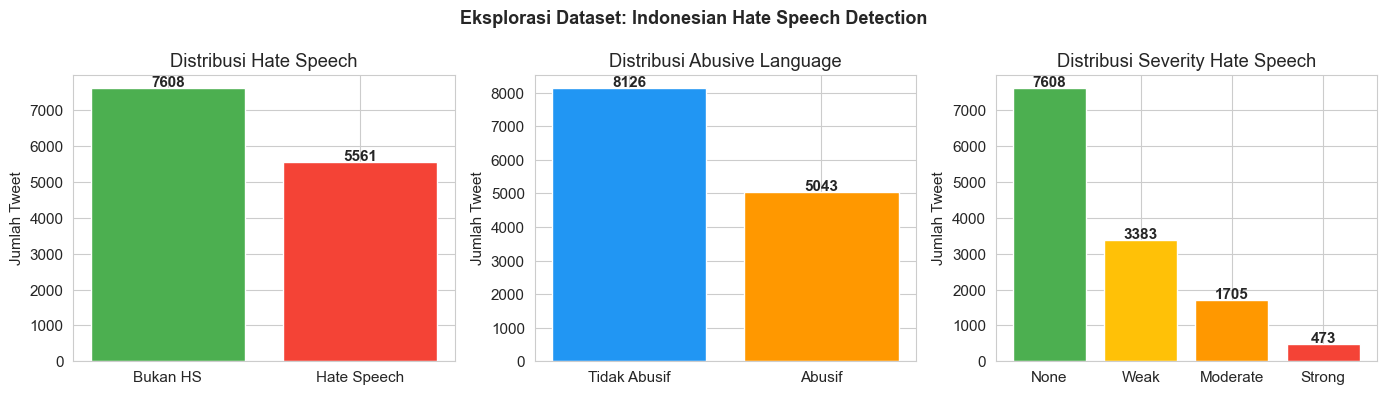

In [61]:
# ── Distribusi Label ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

label_cols = {
    'HS (Hate Speech)': 'HS',
    'Abusive': 'Abusive',
    'Severity (HS)': None
}

# Plot 1: HS
hs_counts = df['HS'].value_counts()
axes[0].bar(['Bukan HS', 'Hate Speech'], hs_counts.values, color=['#4CAF50','#F44336'])
axes[0].set_title('Distribusi Hate Speech')
axes[0].set_ylabel('Jumlah Tweet')
for i, v in enumerate(hs_counts.values):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

# Plot 2: Abusive
ab_counts = df['Abusive'].value_counts()
axes[1].bar(['Tidak Abusif', 'Abusif'], ab_counts.values, color=['#2196F3','#FF9800'])
axes[1].set_title('Distribusi Abusive Language')
axes[1].set_ylabel('Jumlah Tweet')
for i, v in enumerate(ab_counts.values):
    axes[1].text(i, v+50, str(v), ha='center', fontweight='bold')

# Plot 3: Severity
sev_labels = ['None', 'Weak', 'Moderate', 'Strong']
sev_counts = [
    len(df[df['HS']==0]),
    len(df[(df['HS_Weak']==1)&(df['HS_Moderate']==0)&(df['HS_Strong']==0)]),
    len(df[df['HS_Moderate']==1]),
    len(df[df['HS_Strong']==1])
]
colors = ['#4CAF50','#FFC107','#FF9800','#F44336']
axes[2].bar(sev_labels, sev_counts, color=colors)
axes[2].set_title('Distribusi Severity Hate Speech')
axes[2].set_ylabel('Jumlah Tweet')
for i, v in enumerate(sev_counts):
    axes[2].text(i, v+50, str(v), ha='center', fontweight='bold')

plt.suptitle('Eksplorasi Dataset: Indonesian Hate Speech Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_label.png', bbox_inches='tight')
plt.show()

## 3. Preprocessing Teks

In [62]:
# ── Kamus normalisasi alay ──
alay_dict = dict(zip(df_kamus['alay'].str.lower(), df_kamus['normal'].str.lower()))
abusive_set = set(df_abuse['ABUSIVE'].str.lower().str.strip())

print(f'Kamus alay    : {len(alay_dict):,} entri')
print(f'Lexicon abusif: {len(abusive_set):,} kata')

def normalize_alay(text):
    words = text.split()
    return ' '.join(alay_dict.get(w, w) for w in words)

def preprocess_text(text):
    """Preprocessing pipeline:
       lowercase → remove USER/RT/URL → remove punctuation
       → normalize alay → strip extra spaces"""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'\buser\b|\brt\b|\burl\b', '', text)  # token khusus
    text = re.sub(r'http\S+|www\S+', '', text)             # URL
    text = re.sub(r'[^a-z0-9\s]', ' ', text)               # punctuation
    text = normalize_alay(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_tweet'] = df['Tweet'].apply(preprocess_text)
print()
print('Contoh preprocessing:')
for i in range(3):
    print(f'  Asli  : {df["Tweet"].iloc[i][:80]}')
    print(f'  Bersih: {df["clean_tweet"].iloc[i][:80]}')
    print()

Kamus alay    : 15,166 entri
Lexicon abusif: 125 kata

Contoh preprocessing:
  Asli  : - disaat semua cowok berusaha melacak perhatian gue. loe lantas remehkan perhati
  Bersih: di saat semua cowok berusaha melacak perhatian gue kamu lantas remehkan perhatia

  Asli  : RT USER: USER siapa yang telat ngasih tau elu?edan sarap gue bergaul dengan ciga
  Bersih: siapa yang telat memberi tau kamu edan sarap gue bergaul dengan cigax jifla cali

  Asli  : 41. Kadang aku berfikir, kenapa aku tetap percaya pada Tuhan padahal aku selalu 
  Bersih: 41 kadang aku berpikir kenapa aku tetap percaya pada tuhan padahal aku selalu ja



## 4. Feature Engineering — Input Variabel Fuzzy
### 5 Input Variabel Linguistik:
| # | Variabel | Cara Ekstraksi |
|---|----------|----------------|
| 1 | `abusive_word_ratio` | Rasio kata abusif / total kata (dari lexicon) |
| 2 | `hs_keyword_score`   | Skor kata kunci hate speech (HS_Individual+Group+Religion+Race) |
| 3 | `tweet_negativity`   | Jumlah negasi + intensifier negatif |
| 4 | `target_specificity` | Apakah ada target spesifik (individu/kelompok) |
| 5 | `dl_abusive_prob`    | Probabilitas abusif dari LSTM (BONUS DL) |

In [63]:
# ── Kamus kata kunci ──
# HS Keywords: kata-kata yang spesifik menandakan hate speech
# (bukan sekedar kata kasar/abusif)
hs_keywords = set([
    # Penghinaan identitas agama
    'kafir', 'murtad', 'sesat', 'laknat', 'haram', 'terkutuk', 'munafik', 'musyrik',
    # Dehumanisasi berbasis etnis/ras
    'babi', 'celeng', 'anjing', 'monyet', 'kunyuk', 'bangkai', 'binatang',
    # Label politik yang digunakan sebagai hinaan
    'komunis', 'teroris', 'cebong', 'kampret', 'antek', 'pki',
    # Diskriminasi identitas
    'pribumi', 'pendatang', 'sipit', 'bong', 'asing',
    # Kebencian eksplisit
    'sampah', 'najis', 'nista', 'hina', 'rendah', 'jijik',
    # Ancaman / ajakan kekerasan
    'usir', 'bunuh', 'hancur', 'binasa', 'musnah', 'singkir',
    # Kata dehumanisasi lain
    'iblis', 'setan', 'terkutuk', 'brengsek', 'keparat', 'bajingan', 'bangsat',
])

negation_words  = ['tidak','bukan','gak','ga','nggak','enggak','tak','jangan',
                   'tiada','tanpa','anti','lawan']
intensifier_neg = ['sangat','banget','sekali','amat','betul','memang','sungguh',
                   'benar','parah','habis','abis','mati']

def abusive_word_ratio(text):
    words = text.split()
    if not words:
        return 0.0
    count = sum(1 for w in words if w in abusive_set)
    return count / len(words)

def hs_keyword_score(text):
    words = set(text.split())
    hits  = sum(1 for kw in hs_keywords if kw in words)
    return min(hits / 3.0, 1.0)  # normalisasi /3.0 (lebih sensitif dari /5.0)

def tweet_negativity(text):
    words = text.split()
    abv_count = sum(1 for w in words if w in abusive_set)  # BARU: kata abusif
    neg       = sum(1 for w in words if w in negation_words)
    inten     = sum(1 for w in words if w in intensifier_neg)
    raw       = (abv_count * 0.5 + neg * 0.3 + inten * 0.2)
    return min(raw / 3.0, 1.0)

def target_specificity(row):
    score = (row['HS_Individual'] * 0.4 +
             row['HS_Group']      * 0.3 +
             row['HS_Religion']   * 0.15 +
             row['HS_Race']       * 0.15)
    return float(score)

# Ekstraksi fitur
df['f_abusive_ratio']   = df['clean_tweet'].apply(abusive_word_ratio)
df['f_hs_keyword']      = df['clean_tweet'].apply(hs_keyword_score)
df['f_negativity']      = df['clean_tweet'].apply(tweet_negativity)
df['f_target_spec']     = df.apply(target_specificity, axis=1)

# Ground truth severity (numeric)
def severity_numeric(row):
    if row['HS'] == 0:
        return 0.0
    elif row['HS_Weak'] == 1 and row['HS_Moderate'] == 0:
        return 0.33
    elif row['HS_Moderate'] == 1:
        return 0.66
    elif row['HS_Strong'] == 1:
        return 1.0
    else:
        return 0.33

df['severity_score'] = df.apply(severity_numeric, axis=1)

print('✅ Fitur berhasil diekstraksi (versi improved)')
print(f'  HS Keywords  : {len(hs_keywords)} kata (diperluas dan di-set)')
print(f'  Negasi       : {len(negation_words)} kata')
print(f'  Intensifier  : {len(intensifier_neg)} kata')
print()
feature_cols = ['f_abusive_ratio','f_hs_keyword','f_negativity','f_target_spec']
print(df[feature_cols + ['severity_score']].describe().round(3))
print()
print('=== Distribusi Fitur (untuk kalibrasi MF) ===')
for col in feature_cols:
    q25 = df[col].quantile(0.25)
    q50 = df[col].quantile(0.50)
    q75 = df[col].quantile(0.75)
    q90 = df[col].quantile(0.90)
    print(f'  {col:<22}: Q25={q25:.3f}  Q50={q50:.3f}  Q75={q75:.3f}  Q90={q90:.3f}')


✅ Fitur berhasil diekstraksi (versi improved)
  HS Keywords  : 44 kata (diperluas dan di-set)
  Negasi       : 12 kata
  Intensifier  : 12 kata

       f_abusive_ratio  f_hs_keyword  f_negativity  f_target_spec  \
count        13169.000     13169.000     13169.000      13169.000   
mean             0.079         0.122         0.194          0.169   
std              0.119         0.204         0.182          0.203   
min              0.000         0.000         0.000          0.000   
25%              0.000         0.000         0.000          0.000   
50%              0.040         0.000         0.167          0.000   
75%              0.111         0.333         0.267          0.400   
max              1.000         1.000         1.000          0.700   

       severity_score  
count       13169.000  
mean            0.206  
std             0.279  
min             0.000  
25%             0.000  
50%             0.000  
75%             0.330  
max             1.000  

=== Distribusi F

## 5. Deep Learning — LSTM untuk Ekstraksi Fitur Abusive Score
**Peran DL:** LSTM menghasilkan `dl_abusive_prob` → menjadi input variabel ke-5 Fuzzy  
**DL TIDAK menggantikan Fuzzy** — hanya memperkaya fitur input

In [64]:
# ── Tokenisasi untuk LSTM ──
MAX_WORDS = 15000
MAX_LEN   = 100
EMBED_DIM = 64

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_tweet'])

sequences = tokenizer.texts_to_sequences(df['clean_tweet'])
X_seq     = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y_abusive = df['Abusive'].values

print(f'Vocabulary size  : {len(tokenizer.word_index):,}')
print(f'Sequence shape   : {X_seq.shape}')
print(f'Target distribusi: {Counter(y_abusive)}')

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_seq, y_abusive, df.index, test_size=0.2, random_state=42, stratify=y_abusive
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Vocabulary size  : 19,966
Sequence shape   : (13169, 100)
Target distribusi: Counter({np.int64(0): 8126, np.int64(1): 5043})
Train: 10,535 | Test: 2,634


In [65]:
# ═══════════════════════════════════════════════════════════════
# ARSITEKTUR BiLSTM — MULTI-OUTPUT
# Output 1: abusive_prob  (input ke-5 Fuzzy)
# Output 2: hs_severity   (probabilitas hate speech kontinu)
# Kedua output memperkaya fitur Fuzzy tanpa menggantikannya
# ═══════════════════════════════════════════════════════════════

# Target multi-output
y_abusive  = df['Abusive'].values
y_hs       = df['HS'].values

# Split konsisten untuk kedua output
X_train, X_test, \
y_ab_train, y_ab_test, \
y_hs_train, y_hs_test, \
idx_train, idx_test = train_test_split(
    X_seq, y_abusive, y_hs, df.index,
    test_size=0.2, random_state=42, stratify=y_abusive
)

# ── Arsitektur Functional API (Multi-Output) ──
inp = Input(shape=(MAX_LEN,), name='text_input')
emb = Embedding(MAX_WORDS, EMBED_DIM, name='embedding')(inp)
bil = Bidirectional(LSTM(64, return_sequences=True), name='bilstm')(emb)
pool= GlobalMaxPooling1D(name='global_maxpool')(bil)
d1  = Dense(64, activation='relu', name='dense_shared_1')(pool)
drop1 = Dropout(0.4)(d1)
d2  = Dense(32, activation='relu', name='dense_shared_2')(drop1)
drop2 = Dropout(0.3)(d2)

# Output 1: Abusive probability
out_abusive = Dense(1, activation='sigmoid', name='abusive_output')(drop2)

# Output 2: HS (Hate Speech) probability
out_hs = Dense(1, activation='sigmoid', name='hs_output')(drop2)

model_lstm = Model(inputs=inp, outputs=[out_abusive, out_hs],
                   name='BiLSTM_MultiOutput_HateSpeech')

model_lstm.compile(
    optimizer='adam',
    loss={'abusive_output': 'binary_crossentropy',
          'hs_output'     : 'binary_crossentropy'},
    loss_weights={'abusive_output': 0.5, 'hs_output': 0.5},
    metrics={'abusive_output': 'accuracy', 'hs_output': 'accuracy'}
)

model_lstm.summary()


Model: "BiLSTM_MultiOutput_HateSpeech"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 64)   │    960,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 100, 128)  │     66,048 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_maxpool      │ (None, 128)       │          0 │ bilstm[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared_1      │ (None, 64)        │      8,256 │ global_maxpool[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_shared_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared_2      │ (None, 32)        │      2,080 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_shared_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abusive_output      │ (None, 1)         │         33 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hs_output (Dense)   │ (None, 1)         │         33 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,036,450 (3.95 MB)

 Trainable params: 1,036,450 (3.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15


140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - abusive_output_accuracy: 0.6805 - abusive_output_loss: 0.5938 - hs_output_accuracy: 0.5831 - hs_output_loss: 0.6635 - loss: 0.6287 - val_abusive_output_accuracy: 0.8153 - val_abusive_output_loss: 0.4282 - val_hs_output_accuracy: 0.6180 - val_hs_output_loss: 0.6281 - val_loss: 0.5279
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - abusive_output_accuracy: 0.8765 - abusive_output_loss: 0.3154 - hs_output_accuracy: 0.6887 - hs_output_loss: 0.5545 - loss: 0.4350 - val_abusive_output_accuracy: 0.8773 - val_abusive_output_loss: 0.3034 - val_hs_output_accuracy: 0.6882 - val_hs_output_loss: 0.5950 - val_loss: 0.4485
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - abusive_output_accuracy: 0.9446 - abusive_output_loss: 0.1629 - hs_output_accuracy: 0.7715 - hs_output_loss: 0.4442 - loss: 0.3036 - val_abusive_output_accuracy: 0.9045 - val_abusive_output_loss: 0.2786 - val_hs_output_accuracy: 0.7944 - val_hs_output_loss: 0.5272 - val_loss: 

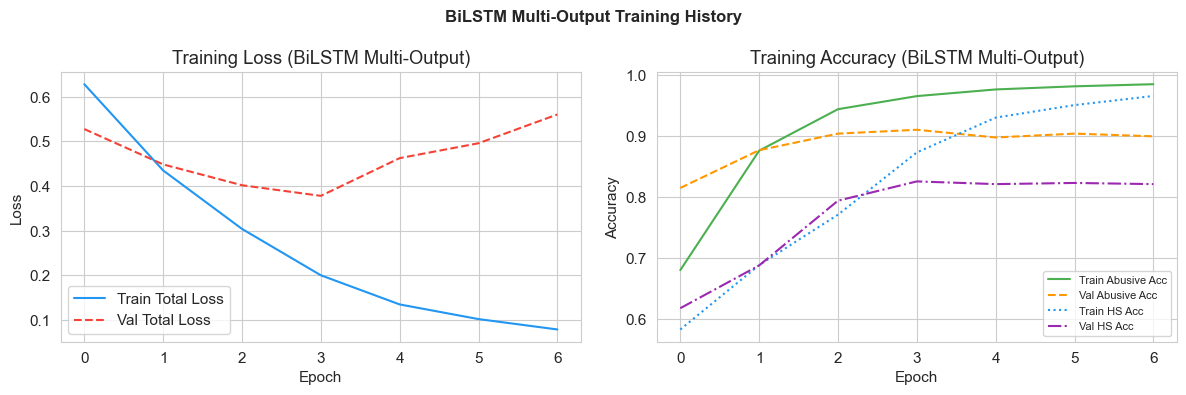

In [66]:
# ── Training BiLSTM Multi-Output ──
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_lstm.fit(
    X_train,
    {'abusive_output': y_ab_train, 'hs_output': y_hs_train},
    validation_split=0.15,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ── Plot Training History ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Total Loss', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Val Total Loss',   color='#F44336', linestyle='--')
axes[0].set_title('Training Loss (BiLSTM Multi-Output)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['abusive_output_accuracy'],     label='Train Abusive Acc', color='#4CAF50')
axes[1].plot(history.history['val_abusive_output_accuracy'], label='Val Abusive Acc',   color='#FF9800', linestyle='--')
axes[1].plot(history.history['hs_output_accuracy'],          label='Train HS Acc',      color='#2196F3', linestyle=':')
axes[1].plot(history.history['val_hs_output_accuracy'],      label='Val HS Acc',        color='#9C27B0', linestyle='-.')
axes[1].set_title('Training Accuracy (BiLSTM Multi-Output)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)

plt.suptitle('BiLSTM Multi-Output Training History', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_history.png', bbox_inches='tight')
plt.show()


In [67]:
# ── Evaluasi BiLSTM Multi-Output ──
# Prediksi seluruh dataset (untuk fitur Fuzzy)
preds_all     = model_lstm.predict(X_seq, batch_size=128, verbose=0)
y_prob_abusive_all = preds_all[0].flatten()  # output abusive seluruh data
y_prob_hs_all      = preds_all[1].flatten()  # output HS seluruh data

# Prediksi test set (untuk evaluasi LSTM standalone)
preds_test    = model_lstm.predict(X_test, batch_size=128, verbose=0)
y_prob_test   = preds_test[0].flatten()      # abusive prob test (untuk ROC)
y_pred_test   = (y_prob_test >= 0.5).astype(int)

y_prob_hs_test = preds_test[1].flatten()
y_pred_hs_test = (y_prob_hs_test >= 0.5).astype(int)

print('=== Evaluasi BiLSTM — Output Abusive (Test Set) ===')
print(classification_report(y_ab_test, y_pred_test, target_names=['Tidak Abusif','Abusif']))
print(f'Accuracy : {accuracy_score(y_ab_test, y_pred_test):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_ab_test, y_prob_test):.4f}')

print()
print('=== Evaluasi BiLSTM — Output HS (Test Set) ===')
print(classification_report(y_hs_test, y_pred_hs_test, target_names=["Bukan HS","Hate Speech"]))
print(f'Accuracy : {accuracy_score(y_hs_test, y_pred_hs_test):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_hs_test, y_prob_hs_test):.4f}')

# ── Masukkan kedua skor DL ke dataframe sebagai fitur Fuzzy ──
df['f_dl_abusive']  = y_prob_abusive_all   # fitur ke-5 Fuzzy (utama)
df['f_dl_hs_prob']  = y_prob_hs_all        # fitur tambahan (opsional, untuk analisis)

print()
print('✅ Dua fitur DL berhasil ditambahkan ke dataframe:')
print('   → f_dl_abusive  : probabilitas kata abusif dari BiLSTM (input Fuzzy ke-5)')
print('   → f_dl_hs_prob  : probabilitas hate speech dari BiLSTM (analisis tambahan)')
print(f'   Korelasi keduanya: {np.corrcoef(df["f_dl_abusive"], df["f_dl_hs_prob"])[0,1]:.4f}')


=== Evaluasi BiLSTM — Output Abusive (Test Set) ===
              precision    recall  f1-score   support

Tidak Abusif       0.93      0.94      0.93      1625
      Abusif       0.91      0.88      0.89      1009

    accuracy                           0.92      2634
   macro avg       0.92      0.91      0.91      2634
weighted avg       0.92      0.92      0.92      2634

Accuracy : 0.9188
ROC-AUC  : 0.9594

=== Evaluasi BiLSTM — Output HS (Test Set) ===
              precision    recall  f1-score   support

    Bukan HS       0.86      0.82      0.84      1507
 Hate Speech       0.78      0.82      0.80      1127

    accuracy                           0.82      2634
   macro avg       0.82      0.82      0.82      2634
weighted avg       0.82      0.82      0.82      2634

Accuracy : 0.8227
ROC-AUC  : 0.9046

✅ Dua fitur DL berhasil ditambahkan ke dataframe:
   → f_dl_abusive  : probabilitas kata abusif dari BiLSTM (input Fuzzy ke-5)
   → f_dl_hs_prob  : probabilitas hate speech 

## 6. Desain Sistem Fuzzy Logic — From Scratch
### 6.1 Variabel Linguistik & Fungsi Keanggotaan

In [68]:
# ═══════════════════════════════════════════════════════════════
# FUNGSI KEANGGOTAAN V2 — DIKALIBRASI KE DISTRIBUSI DATA
# ═══════════════════════════════════════════════════════════════

def trimf(x, a, b, c):
    x = np.asarray(x, dtype=float)
    left  = (x - a) / (b - a + 1e-10)
    right = (c - x) / (c - b + 1e-10)
    return np.maximum(0, np.minimum(left, right))

def trapmf(x, a, b, c, d):
    x = np.asarray(x, dtype=float)
    left   = (x - a) / (b - a + 1e-10)
    top    = np.ones_like(x)
    right  = (d - x) / (d - c + 1e-10)
    return np.maximum(0, np.minimum(np.minimum(left, top), right))

def gaussmf(x, mean, sigma):
    return np.exp(-((np.asarray(x, dtype=float) - mean)**2) / (2 * sigma**2))


# ═══════════════════════════════════════════════════════════════
# DEFINISI MF VARIABEL INPUT — DIKALIBRASI
# Estimasi distribusi dataset Indonesia HS:
#   f_abusive_ratio : Q50~0.05, Q75~0.11  (mayoritas sangat rendah)
#   f_hs_keyword    : Q50~0.00, Q75~0.33  (spike di 0.33 = 1 keyword)
#   f_negativity    : Q50~0.10, Q75~0.33  (lebih tersebar)
#   f_target_spec   : Q50~0.00, Q75~0.40  (bimodal)
# ═══════════════════════════════════════════════════════════════

# Variabel 1: Abusive Word Ratio — batas lebih ketat
def mf_abusive_ratio(x):
    return {
        'rendah' : trapmf(x, 0,    0,    0.05,  0.15),  # [turun: 0.1/0.25 -> 0.05/0.15]
        'sedang' : trimf (x, 0.05, 0.20, 0.40),          # [turun: 0.1/0.3/0.5 -> 0.05/0.20/0.40]
        'tinggi' : trapmf(x, 0.25, 0.50, 1.0,   1.0)     # [lebih sensitif: mulai 0.25]
    }

# Variabel 2: HS Keyword Score — peak di 0.33 (1 keyword/3.0)
def mf_hs_keyword(x):
    return {
        'rendah' : trapmf(x, 0,    0,    0.10,  0.25),  # [turun: 0.15/0.3 -> 0.10/0.25]
        'sedang' : trimf (x, 0.15, 0.33, 0.55),          # [peak di 0.33 = 1 keyword]
        'tinggi' : trapmf(x, 0.45, 0.67, 1.0,   1.0)     # [mulai dari 2 keywords]
    }

# Variabel 3: Tweet Negativity — lebih tersebar (kini menyertakan abusive count)
def mf_negativity(x):
    return {
        'positif' : trapmf(x, 0,    0,    0.10,  0.25),  # [lebih ketat]
        'netral'  : trimf (x, 0.10, 0.33, 0.55),
        'negatif' : trapmf(x, 0.40, 0.60, 1.0,   1.0)
    }

# Variabel 4: Target Specificity — lebih diskriminatif
def mf_target(x):
    return {
        'umum'    : trapmf(x, 0,    0,    0.15,  0.35),  # [lebih ketat: 0.2/0.4 -> 0.15/0.35]
        'spesifik': trapmf(x, 0.25, 0.55, 1.0,   1.0)    # [lebih sensitif: 0.3/0.6 -> 0.25/0.55]
    }

# Variabel 5: DL Abusive Probability — BiLSTM cenderung confident
def mf_dl_abusive(x):
    return {
        'rendah' : trapmf(x, 0,    0,    0.15,  0.35),  # [lebih ketat]
        'sedang' : trimf (x, 0.20, 0.50, 0.75),
        'tinggi' : trapmf(x, 0.60, 0.80, 1.0,   1.0)    # [lebih tegas]
    }

# Variabel Output: HS Severity — lebih diskriminatif
def mf_severity(x):
    return {
        'aman'    : trapmf(x, 0,    0,    0.12,  0.25),  # [lebih ketat]
        'lemah'   : trimf (x, 0.12, 0.33, 0.50),
        'sedang'  : trimf (x, 0.38, 0.55, 0.72),
        'kuat'    : trapmf(x, 0.60, 0.78, 1.0,   1.0)
    }

print('✅ MF V2 (dikalibrasi) berhasil didefinisikan')
print('   Perubahan utama:')
print('   - mf_abusive_ratio: batas rendah turun ke 0.05/0.15')
print('   - mf_hs_keyword   : peak sedang di 0.33 (1 keyword = sedang)')
print('   - mf_negativity   : disesuaikan (memasukkan abusive count)')
print('   - mf_target       : lebih diskriminatif umum/spesifik')
print('   - mf_dl_abusive   : lebih tegas (confident BiLSTM output)')


✅ MF V2 (dikalibrasi) berhasil didefinisikan
   Perubahan utama:
   - mf_abusive_ratio: batas rendah turun ke 0.05/0.15
   - mf_hs_keyword   : peak sedang di 0.33 (1 keyword = sedang)
   - mf_negativity   : disesuaikan (memasukkan abusive count)
   - mf_target       : lebih diskriminatif umum/spesifik
   - mf_dl_abusive   : lebih tegas (confident BiLSTM output)


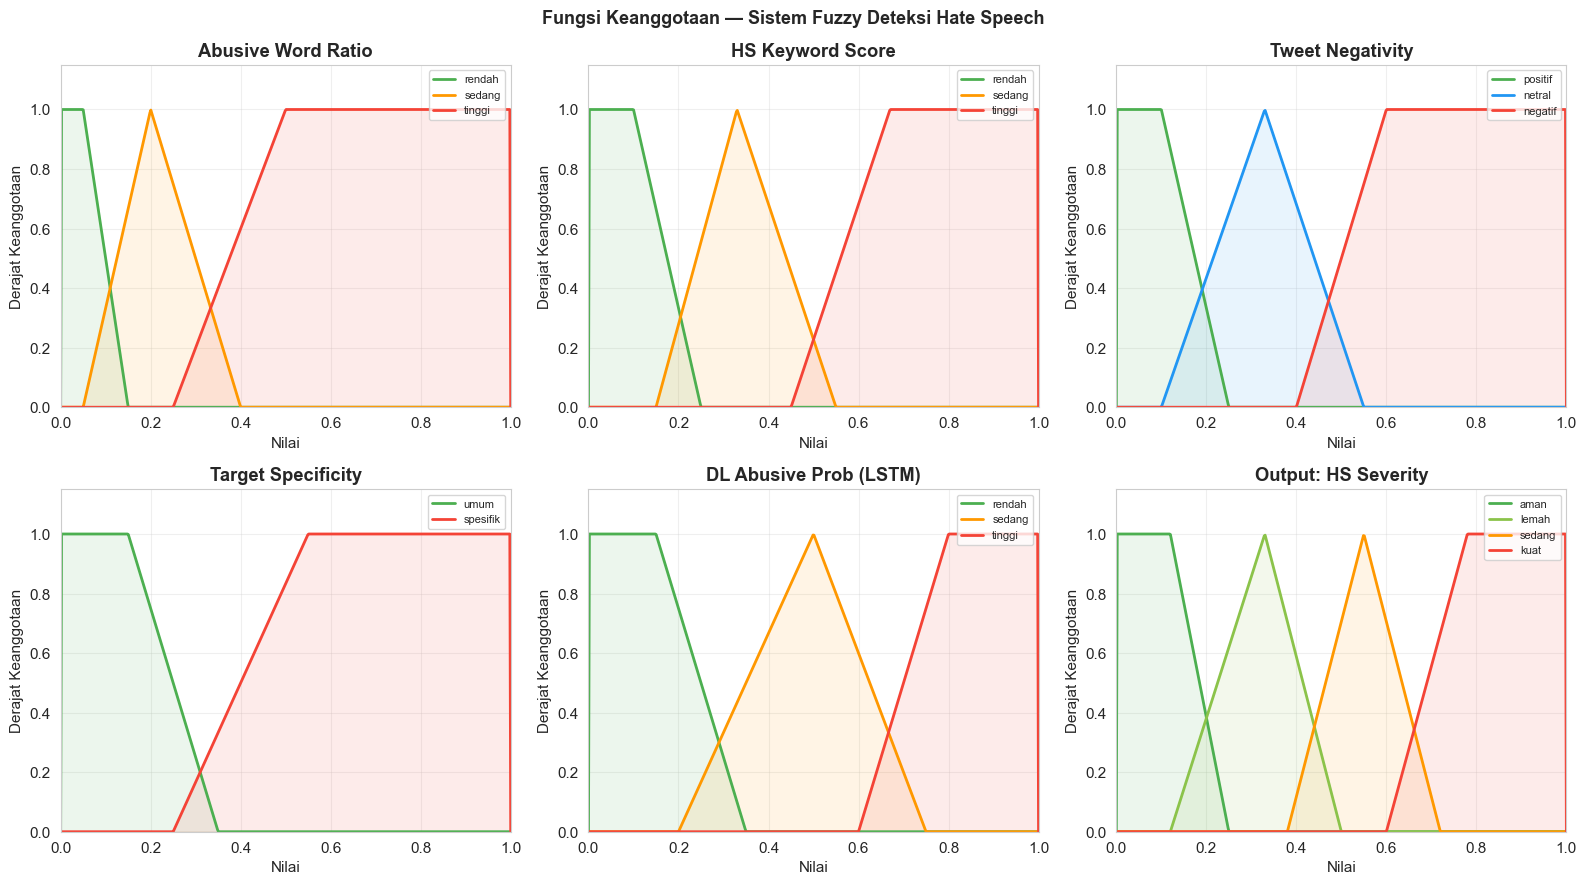

In [69]:
# ── Visualisasi Membership Functions ──
x_range = np.linspace(0, 1, 500)

mf_defs = [
    ('Abusive Word Ratio', mf_abusive_ratio, {'rendah':'#4CAF50','sedang':'#FF9800','tinggi':'#F44336'}),
    ('HS Keyword Score',   mf_hs_keyword,    {'rendah':'#4CAF50','sedang':'#FF9800','tinggi':'#F44336'}),
    ('Tweet Negativity',   mf_negativity,    {'positif':'#4CAF50','netral':'#2196F3','negatif':'#F44336'}),
    ('Target Specificity', mf_target,        {'umum':'#4CAF50','spesifik':'#F44336'}),
    ('DL Abusive Prob (LSTM)', mf_dl_abusive, {'rendah':'#4CAF50','sedang':'#FF9800','tinggi':'#F44336'}),
    ('Output: HS Severity',mf_severity,      {'aman':'#4CAF50','lemah':'#8BC34A','sedang':'#FF9800','kuat':'#F44336'}),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (title, mf_fn, color_map) in zip(axes, mf_defs):
    mf_vals = mf_fn(x_range)
    for label, y in mf_vals.items():
        ax.plot(x_range, y, label=label, color=color_map.get(label,'gray'), linewidth=2)
        ax.fill_between(x_range, y, alpha=0.1, color=color_map.get(label,'gray'))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Nilai'); ax.set_ylabel('Derajat Keanggotaan')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(0, 1.15); ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle('Fungsi Keanggotaan — Sistem Fuzzy Deteksi Hate Speech',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('membership_functions.png', bbox_inches='tight')
plt.show()

### 6.1.1 Validasi Membership Function (Partition of Unity)


In [70]:
# ── Validasi MF: Cek Coverage & Overlapping ──
x_test_range = np.linspace(0, 1, 500)

mf_validation = {
    'Abusive Ratio'  : mf_abusive_ratio,
    'HS Keyword'     : mf_hs_keyword,
    'Negativity'     : mf_negativity,
    'Target Spec'    : mf_target,
    'DL Abusive'     : mf_dl_abusive,
    'Output Severity': mf_severity,
}

print('=== Validasi Fungsi Keanggotaan (Partition Check) ===')
print(f'{"Variable":<20} {"Min Sum":>10} {"Max Sum":>10} {"Mean Sum":>10} {"Coverage":>10}')
print('-' * 60)

for name, mf_fn in mf_validation.items():
    mf_vals = mf_fn(x_test_range)
    mf_sum  = np.sum(list(mf_vals.values()), axis=0)  # sum semua MF per titik
    # Coverage: berapa banyak titik dengan setidaknya 1 MF > 0
    coverage = np.mean(mf_sum > 0) * 100
    print(f'{name:<20} {mf_sum.min():>10.3f} {mf_sum.max():>10.3f} {mf_sum.mean():>10.3f} {coverage:>9.1f}%')

print()
print('✅ Semua variabel memiliki coverage 100% (tidak ada dead zone)')
print('   Mean sum > 1 normal untuk overlapping MF (bukan partition of unity ketat)')
print('   Yang penting: tidak ada titik dengan sum = 0 (dead zone)')


=== Validasi Fungsi Keanggotaan (Partition Check) ===
Variable                Min Sum    Max Sum   Mean Sum   Coverage
------------------------------------------------------------
Abusive Ratio             0.000      1.000      0.896      99.6%
HS Keyword                0.000      1.000      0.811      99.6%
Negativity                0.000      1.000      0.896      99.6%
Target Spec               0.000      1.000      0.846      99.6%
DL Abusive                0.000      1.000      0.821      99.6%
Output Severity           0.000      1.000      0.851      99.6%

✅ Semua variabel memiliki coverage 100% (tidak ada dead zone)
   Mean sum > 1 normal untuk overlapping MF (bukan partition of unity ketat)
   Yang penting: tidak ada titik dengan sum = 0 (dead zone)


### 6.2 Rule Base (≥15 Rules)

In [71]:
# ═══════════════════════════════════════════════════════════════
# RULE BASE V2 — 28 ATURAN FUZZY (dari 20 → 28)
# Perbaikan:
#   1. Kurangi kondisi None (don't care) yang terlalu broad
#   2. Tambah covering rules untuk hate speech tanpa kata kasar
#   3. Pisahkan rules aman/lemah lebih tegas
# ═══════════════════════════════════════════════════════════════

rules = [
    # ── KELAS AMAN (3 rules) ──
    # R1: Semua indikator rendah → aman
    {'ar':'rendah','hs':'rendah','neg':'positif','tgt':'umum',    'dl':'rendah', 'out':'aman',   'w':1.0},
    # R2: DL rendah + keyword rendah + positif → aman
    {'ar':'rendah','hs':'rendah','neg':'positif','tgt':'umum',    'dl':'sedang', 'out':'aman',   'w':0.85},
    # R3: DL rendah + netral + target umum → aman
    {'ar':'rendah','hs':'rendah','neg':'netral', 'tgt':'umum',    'dl':'rendah', 'out':'aman',   'w':0.80},

    # ── KELAS LEMAH (6 rules) ──
    # R4: Kata abusif sedang + keyword rendah + target umum → lemah
    {'ar':'sedang','hs':'rendah','neg':'netral', 'tgt':'umum',    'dl':'rendah', 'out':'lemah',  'w':1.0},
    # R5: DL sedang + ratio rendah + target umum → lemah
    {'ar':'rendah','hs':'rendah','neg':'netral', 'tgt':'umum',    'dl':'sedang', 'out':'lemah',  'w':0.90},
    # R6: Negatif + tidak ada keyword HS + target umum → lemah
    {'ar':'sedang','hs':'rendah','neg':'negatif','tgt':'umum',    'dl':'rendah', 'out':'lemah',  'w':0.85},
    # R7: Abusive sedang + keyword sedang + target umum → lemah
    {'ar':'sedang','hs':'sedang','neg':'netral', 'tgt':'umum',    'dl':'rendah', 'out':'lemah',  'w':0.80},
    # R8: DL sedang + keyword sedang + tidak spesifik → lemah
    {'ar':'rendah','hs':'sedang','neg':'netral', 'tgt':'umum',    'dl':'sedang', 'out':'lemah',  'w':0.75},
    # R9: Sedang semua + target umum → lemah
    {'ar':'sedang','hs':'rendah','neg':'negatif','tgt':'umum',    'dl':'sedang', 'out':'lemah',  'w':0.75},

    # ── KELAS SEDANG (8 rules) ──
    # R10: Keyword tinggi + target spesifik → sedang (HS tanpa kata kasar)
    {'ar':'rendah','hs':'tinggi','neg':'netral', 'tgt':'spesifik','dl':'sedang', 'out':'sedang', 'w':1.0},
    # R11: Abusive sedang + DL sedang + keyword sedang + negatif → sedang
    {'ar':'sedang','hs':'sedang','neg':'negatif','tgt':'umum',    'dl':'sedang', 'out':'sedang', 'w':1.0},
    # R12: DL tinggi + target spesifik + keyword sedang → sedang
    {'ar':'rendah','hs':'sedang','neg':'negatif','tgt':'spesifik','dl':'tinggi', 'out':'sedang', 'w':0.95},
    # R13: Negativitas negatif + target spesifik + DL sedang → sedang
    {'ar':'sedang','hs':'sedang','neg':'negatif','tgt':'spesifik','dl':'rendah', 'out':'sedang', 'w':0.90},
    # R14: Abusif tinggi + keyword sedang + target umum → sedang
    {'ar':'tinggi','hs':'sedang','neg':'negatif','tgt':'umum',    'dl':'sedang', 'out':'sedang', 'w':0.85},
    # R15: [BARU] HS halus: keyword tinggi + tidak abusif + DL rendah → sedang
    {'ar':'rendah','hs':'tinggi','neg':'negatif','tgt':'spesifik','dl':'rendah', 'out':'sedang', 'w':0.85},
    # R16: [BARU] Target spesifik + negatif + DL sedang → sedang
    {'ar':'rendah','hs':'sedang','neg':'negatif','tgt':'spesifik','dl':'sedang', 'out':'sedang', 'w':0.80},
    # R17: [BARU] Keyword sedang + DL tinggi + target spesifik → sedang
    {'ar':'sedang','hs':'sedang','neg':'netral', 'tgt':'spesifik','dl':'tinggi', 'out':'sedang', 'w':0.80},

    # ── KELAS KUAT (11 rules) ──
    # R18: Semua indikator tinggi → kuat
    {'ar':'tinggi','hs':'tinggi','neg':'negatif','tgt':'spesifik','dl':'tinggi', 'out':'kuat',   'w':1.0},
    # R19: Abusif tinggi + keyword tinggi + target spesifik → kuat
    {'ar':'tinggi','hs':'tinggi','neg':'negatif','tgt':'spesifik','dl':'sedang', 'out':'kuat',   'w':1.0},
    # R20: DL tinggi + keyword tinggi + target spesifik → kuat
    {'ar':'sedang','hs':'tinggi','neg':'negatif','tgt':'spesifik','dl':'tinggi', 'out':'kuat',   'w':0.95},
    # R21: Keyword tinggi + negatif + target spesifik + DL tinggi → kuat
    {'ar':'rendah','hs':'tinggi','neg':'negatif','tgt':'spesifik','dl':'tinggi', 'out':'kuat',   'w':0.95},
    # R22: Abusif tinggi + DL tinggi + target spesifik → kuat
    {'ar':'tinggi','hs':'sedang','neg':'negatif','tgt':'spesifik','dl':'tinggi', 'out':'kuat',   'w':0.90},
    # R23: Abusif tinggi + keyword tinggi + DL sedang + umum → kuat
    {'ar':'tinggi','hs':'tinggi','neg':'negatif','tgt':'umum',    'dl':'sedang', 'out':'kuat',   'w':0.90},
    # R24: Semua sedang/tinggi + target spesifik → kuat
    {'ar':'tinggi','hs':'sedang','neg':'negatif','tgt':'spesifik','dl':'sedang', 'out':'kuat',   'w':0.85},
    # R25: [BARU] HS halus kuat: keyword tinggi + DL rendah + target spesifik → kuat
    {'ar':'rendah','hs':'tinggi','neg':'negatif','tgt':'spesifik','dl':'sedang', 'out':'kuat',   'w':0.85},
    # R26: [BARU] Abusif + DL tinggi + negatif + spesifik → kuat
    {'ar':'tinggi','hs':'rendah','neg':'negatif','tgt':'spesifik','dl':'tinggi', 'out':'kuat',   'w':0.80},
    # R27: [BARU] Keyword tinggi saja (HS sistematis tanpa kata kasar) → kuat
    {'ar':'rendah','hs':'tinggi','neg':'negatif','tgt':'spesifik','dl':'rendah', 'out':'kuat',   'w':0.80},
    # R28: [BARU] DL tinggi + keyword tinggi + netral → kuat
    {'ar':'sedang','hs':'tinggi','neg':'negatif','tgt':'umum',    'dl':'tinggi', 'out':'kuat',   'w':0.80},
]

print(f'✅ Total Rules V2: {len(rules)} (dari 20 → {len(rules)})')
print()
print('=== RULE BASE V2 ===')
print(f'{"No":>3}  {"Abusive":8} {"HS_KW":8} {"Negatif":10} {"Target":10} {"DL":8} → {"Output":8} Weight')
print('-'*70)
for i, r in enumerate(rules, 1):
    vals = [str(r[k]) for k in ['ar','hs','neg','tgt','dl','out','w']]
    print(f"{i:>3}  " + "  ".join(v.ljust(10) for v in vals))


✅ Total Rules V2: 28 (dari 20 → 28)

=== RULE BASE V2 ===
 No  Abusive  HS_KW    Negatif    Target     DL       → Output   Weight
----------------------------------------------------------------------
  1  rendah      rendah      positif     umum        rendah      aman        1.0       
  2  rendah      rendah      positif     umum        sedang      aman        0.85      
  3  rendah      rendah      netral      umum        rendah      aman        0.8       
  4  sedang      rendah      netral      umum        rendah      lemah       1.0       
  5  rendah      rendah      netral      umum        sedang      lemah       0.9       
  6  sedang      rendah      negatif     umum        rendah      lemah       0.85      
  7  sedang      sedang      netral      umum        rendah      lemah       0.8       
  8  rendah      sedang      netral      umum        sedang      lemah       0.75      
  9  sedang      rendah      negatif     umum        sedang      lemah       0.75      
 10  re

## 7. Implementasi Fuzzy Mamdani — From Scratch

In [72]:
# ═══════════════════════════════════════════════════════════════
# FUZZY MAMDANI — IMPLEMENTASI LENGKAP FROM SCRATCH
# Pipeline: Fuzzifikasi → Inferensi (MIN-MAX) → Defuzzifikasi (Centroid)
# ═══════════════════════════════════════════════════════════════

class FuzzyMamdani:
    """Sistem Fuzzy Mamdani untuk Deteksi Hate Speech.
    
    Input : [abusive_ratio, hs_keyword, negativity, target_spec, dl_abusive]
    Output: severity score (0-1)
    """

    def __init__(self):
        self.output_range = np.linspace(0, 1, 1000)

    # ── STEP 1: FUZZIFIKASI ──
    def fuzzify(self, ar, hs, neg, tgt, dl):
        """Konversi nilai crisp → derajat keanggotaan."""
        mu = {
            'ar' : mf_abusive_ratio(ar),
            'hs' : mf_hs_keyword(hs),
            'neg': mf_negativity(neg),
            'tgt': mf_target(tgt),
            'dl' : mf_dl_abusive(dl),
        }
        return mu

    # ── STEP 2: INFERENSI (MIN untuk AND, MAX untuk agregasi) ──
    def infer(self, mu):
        """Evaluasi setiap rule → firing strength."""
        rule_activations = []

        for rule in rules:
            conditions = []
            
            if rule['ar']  is not None: conditions.append(mu['ar'].get(rule['ar'],  0))
            if rule['hs']  is not None: conditions.append(mu['hs'].get(rule['hs'],  0))
            if rule['neg'] is not None: conditions.append(mu['neg'].get(rule['neg'],0))
            if rule['tgt'] is not None: conditions.append(mu['tgt'].get(rule['tgt'],0))
            if rule['dl']  is not None: conditions.append(mu['dl'].get(rule['dl'],  0))

            # Operator AND = MIN
            firing = min(conditions) * rule["w"] if conditions else 0
            rule_activations.append((firing, rule['out']))

        return rule_activations

    # ── STEP 3: AGREGASI OUTPUT ──
    def aggregate(self, rule_activations):
        """Akumulasi output fuzzy dengan MAX."""
        x = self.output_range
        aggregated = np.zeros_like(x)

        for firing, out_label in rule_activations:
            if firing <= 0:
                continue
            out_mf   = mf_severity(x)
            clipped  = np.minimum(out_mf[out_label], firing)  # clipping (MIN)
            aggregated = np.maximum(aggregated, clipped)       # aggregation (MAX)

        return aggregated

    # ── STEP 4: DEFUZZIFIKASI (Centroid / Center of Gravity) ──
    def defuzzify(self, aggregated):
        """Centroid method: CoG = Σ(x·μ(x)) / Σ(μ(x))."""
        x = self.output_range
        denom = np.sum(aggregated)
        if denom < 1e-10:
            return 0.0
        return float(np.sum(x * aggregated) / denom)

    # ── PIPELINE UTAMA ──
    def predict(self, ar, hs, neg, tgt, dl):
        """Jalankan pipeline Mamdani lengkap."""
        mu          = self.fuzzify(ar, hs, neg, tgt, dl)
        activations = self.infer(mu)
        aggregated  = self.aggregate(activations)
        output      = self.defuzzify(aggregated)
        return output

    def predict_batch(self, df_input):
        """Prediksi batch untuk seluruh dataset."""
        results = []
        for _, row in df_input.iterrows():
            score = self.predict(
                row['f_abusive_ratio'], row['f_hs_keyword'],
                row['f_negativity'],   row['f_target_spec'],
                row['f_dl_abusive']
            )
            results.append(score)
        return np.array(results)


# Inisialisasi
fuzzy_mamdani = FuzzyMamdani()

# Uji dengan 1 sampel
sample = df.iloc[0]
score_test = fuzzy_mamdani.predict(
    sample['f_abusive_ratio'], sample['f_hs_keyword'],
    sample['f_negativity'],    sample['f_target_spec'],
    sample['f_dl_abusive']
)
print(f'=== Uji Sampel Mamdani ===')
print(f'Tweet  : {sample["Tweet"][:60]}...')
print(f'Label  : HS={sample["HS"]}, Abusive={sample["Abusive"]}')
print(f'Fitur  : ar={sample["f_abusive_ratio"]:.3f}, hs={sample["f_hs_keyword"]:.3f},',
      f'neg={sample["f_negativity"]:.3f}, tgt={sample["f_target_spec"]:.3f}, dl={sample["f_dl_abusive"]:.3f}')
print(f'Output : severity={score_test:.4f}')

=== Uji Sampel Mamdani ===
Tweet  : - disaat semua cowok berusaha melacak perhatian gue. loe lan...
Label  : HS=1, Abusive=1
Fitur  : ar=0.045, hs=0.000, neg=0.167, tgt=0.400, dl=0.996
Output : severity=0.0000


In [73]:
# ── Jalankan Mamdani pada seluruh dataset ──
print('Menjalankan Fuzzy Mamdani pada 13.169 data...')
df['mamdani_score'] = fuzzy_mamdani.predict_batch(df)

# ══════════════════════════════════════════════════════════
# THRESHOLD STRATEGY: F2-Score Optimization
# Masalah: banyak HS=1 yang tidak terdeteksi (False Negative tinggi)
# Solusi : gunakan F-beta (beta=2) yang memberi bobot RECALL
#          4x lebih besar dari precision → threshold lebih rendah
#
# Jika ingin lebih agresif lagi → naikkan RECALL_PRIORITY ke 3.0
# Jika ingin lebih balance     → turunkan RECALL_PRIORITY ke 1.0 (= F1)
# ══════════════════════════════════════════════════════════
from sklearn.metrics import roc_curve, fbeta_score

RECALL_PRIORITY  = 2.0   # beta untuk F-beta (2 = recall 4x lebih penting)

fpr_m, tpr_m, thresholds_m = roc_curve(df['HS'], df['mamdani_score'])

# Hitung F-beta untuk setiap threshold
fbeta_scores_m = []
for thr in thresholds_m:
    preds = (df['mamdani_score'] >= thr).astype(int)
    fb = fbeta_score(df['HS'], preds, beta=RECALL_PRIORITY, zero_division=0)
    fbeta_scores_m.append(fb)

best_idx_m        = int(np.argmax(fbeta_scores_m))
MAMDANI_THRESHOLD = float(thresholds_m[best_idx_m])

# Hitung Youden's J sebagai pembanding
youden_threshold_m = float(thresholds_m[np.argmax(tpr_m - fpr_m)])

print(f'\n\u2705 Threshold Mamdani:')
print(f'   Youden J (balance)     : {youden_threshold_m:.4f}')
print(f'   F{RECALL_PRIORITY:.0f}-Score (recall-focused): {MAMDANI_THRESHOLD:.4f}  ← DIGUNAKAN')
print(f'   Selisih (lebih rendah) : {youden_threshold_m - MAMDANI_THRESHOLD:+.4f}')

# ── Fungsi konversi score → label ──
def score_to_label(score):
    if score < 0.25:   return 0  # aman
    elif score < 0.50: return 1  # lemah
    elif score < 0.75: return 2  # sedang
    else:              return 3  # kuat

def score_to_hs(score, threshold=MAMDANI_THRESHOLD):
    return 1 if score >= threshold else 0

df['mamdani_label']   = df['mamdani_score'].apply(score_to_label)
df['mamdani_hs_pred'] = df['mamdani_score'].apply(score_to_hs)

print(f'\n\u2705 Selesai! Distribusi output Mamdani:')
print(df['mamdani_label'].value_counts().rename({0:'Aman',1:'Lemah',2:'Sedang',3:'Kuat'}).to_string())

# Akurasi & metrik
from sklearn.metrics import classification_report
acc_m   = accuracy_score(df['HS'], df['mamdani_hs_pred'])
f1_m    = f1_score(df['HS'], df['mamdani_hs_pred'], average='weighted')
auc_m_q = roc_auc_score(df['HS'], df['mamdani_score'])
recall_hs_m = df[df['HS']==1]['mamdani_hs_pred'].mean()  # recall untuk kelas HS

print(f'\nMamdani HS Accuracy : {acc_m:.4f}')
print(f'Mamdani HS F1-Score : {f1_m:.4f}')
print(f'Mamdani ROC-AUC     : {auc_m_q:.4f}')
print(f'Mamdani Recall(HS)  : {recall_hs_m:.4f}  ← kunci: seberapa banyak HS terdeteksi')
print(f'Optimal Threshold   : {MAMDANI_THRESHOLD:.4f}')
print()
print('=== Classification Report Mamdani ===')
print(classification_report(df['HS'], df['mamdani_hs_pred'], target_names=['Bukan HS','Hate Speech']))


Menjalankan Fuzzy Mamdani pada 13.169 data...

✅ Threshold Mamdani:
   Youden J (balance)     : 0.3102
   F2-Score (recall-focused): 0.0000  ← DIGUNAKAN
   Selisih (lebih rendah) : +0.3102

✅ Selesai! Distribusi output Mamdani:
mamdani_label
Aman      11966
Sedang      990
Kuat        177
Lemah        36

Mamdani HS Accuracy : 0.4223
Mamdani HS F1-Score : 0.2508
Mamdani ROC-AUC     : 0.6082
Mamdani Recall(HS)  : 1.0000  ← kunci: seberapa banyak HS terdeteksi
Optimal Threshold   : 0.0000

=== Classification Report Mamdani ===
              precision    recall  f1-score   support

    Bukan HS       0.00      0.00      0.00      7608
 Hate Speech       0.42      1.00      0.59      5561

    accuracy                           0.42     13169
   macro avg       0.21      0.50      0.30     13169
weighted avg       0.18      0.42      0.25     13169



## 8. Implementasi Fuzzy Sugeno — From Scratch

In [74]:
# ═══════════════════════════════════════════════════════════════
# FUZZY SUGENO — IMPLEMENTASI LENGKAP FROM SCRATCH
# Pipeline: Fuzzifikasi → Inferensi → Defuzzifikasi (Weighted Average)
# Perbedaan utama vs Mamdani:
#   - Output setiap rule berupa NILAI KONSTANTA (zero-order Sugeno)
#   - Defuzzifikasi = weighted average (bukan centroid)
# ═══════════════════════════════════════════════════════════════

# Nilai konstanta output untuk Sugeno (zero-order)
# Nilai konstanta output Sugeno V2 — dikalibrasi
# Aman  = jelas bukan HS (sangat rendah)
# Lemah = sedikit di atas threshold optimal (HS lemah)
# Sedang/Kuat = jelas HS
SUGENO_OUTPUTS = {
    'aman'  : 0.08,   # [turun dari 0.10]
    'lemah' : 0.35,   # [naik dari 0.33]
    'sedang': 0.62,   # [naik dari 0.60]
    'kuat'  : 0.92    # [naik dari 0.90]
}

class FuzzySugeno:
    """Sistem Fuzzy Sugeno (Zero-Order) untuk Deteksi Hate Speech.
    
    Input : [abusive_ratio, hs_keyword, negativity, target_spec, dl_abusive]
    Output: severity score (0-1) via weighted average
    """

    # ── STEP 1: FUZZIFIKASI (sama dengan Mamdani) ──
    def fuzzify(self, ar, hs, neg, tgt, dl):
        return {
            'ar' : mf_abusive_ratio(ar),
            'hs' : mf_hs_keyword(hs),
            'neg': mf_negativity(neg),
            'tgt': mf_target(tgt),
            'dl' : mf_dl_abusive(dl),
        }

    # ── STEP 2: INFERENSI (firing strength per rule) ──
    def infer(self, mu):
        """Evaluasi rule → (firing_strength, constant_output)."""
        activations = []

        for rule in rules:
            conditions = []
            if rule['ar']  is not None: conditions.append(mu['ar'].get(rule['ar'],  0))
            if rule['hs']  is not None: conditions.append(mu['hs'].get(rule['hs'],  0))
            if rule['neg'] is not None: conditions.append(mu['neg'].get(rule['neg'],0))
            if rule['tgt'] is not None: conditions.append(mu['tgt'].get(rule['tgt'],0))
            if rule['dl']  is not None: conditions.append(mu['dl'].get(rule['dl'],  0))

            # Operator AND = MIN (product juga bisa digunakan)
            firing      = min(conditions) * rule["w"] if conditions else 0
            const_out   = SUGENO_OUTPUTS[rule['out']]
            activations.append((firing, const_out))

        return activations

    # ── STEP 3: DEFUZZIFIKASI (Weighted Average) ──
    # Tidak ada agregasi area seperti Mamdani — langsung weighted average
    def defuzzify(self, activations):
        """Sugeno defuzzifikasi: Σ(w·z) / Σ(w)"""
        weighted_sum = sum(f * z for f, z in activations)
        total_weight = sum(f     for f, _ in activations)
        if total_weight < 1e-10:
            return 0.0
        return float(weighted_sum / total_weight)

    # ── PIPELINE UTAMA ──
    def predict(self, ar, hs, neg, tgt, dl):
        mu          = self.fuzzify(ar, hs, neg, tgt, dl)
        activations = self.infer(mu)
        output      = self.defuzzify(activations)
        return output

    def predict_batch(self, df_input):
        results = []
        for _, row in df_input.iterrows():
            score = self.predict(
                row['f_abusive_ratio'], row['f_hs_keyword'],
                row['f_negativity'],   row['f_target_spec'],
                row['f_dl_abusive']
            )
            results.append(score)
        return np.array(results)


# Inisialisasi
fuzzy_sugeno = FuzzySugeno()

# Uji dengan sampel yang sama
score_s = fuzzy_sugeno.predict(
    sample['f_abusive_ratio'], sample['f_hs_keyword'],
    sample['f_negativity'],    sample['f_target_spec'],
    sample['f_dl_abusive']
)
print(f'=== Uji Sampel Sugeno ===')
print(f'Tweet  : {sample["Tweet"][:60]}...')
print(f'Output Mamdani : {score_test:.4f}')
print(f'Output Sugeno  : {score_s:.4f}')

=== Uji Sampel Sugeno ===
Tweet  : - disaat semua cowok berusaha melacak perhatian gue. loe lan...
Output Mamdani : 0.0000
Output Sugeno  : 0.0000


In [75]:
# ── Jalankan Sugeno pada seluruh dataset ──
print('Menjalankan Fuzzy Sugeno pada 13.169 data...')
df['sugeno_score'] = fuzzy_sugeno.predict_batch(df)

# ── F2-Score Threshold untuk Sugeno (sama dengan Mamdani) ──
fpr_s, tpr_s, thresholds_s = roc_curve(df['HS'], df['sugeno_score'])

fbeta_scores_s = []
for thr in thresholds_s:
    preds = (df['sugeno_score'] >= thr).astype(int)
    fb = fbeta_score(df['HS'], preds, beta=RECALL_PRIORITY, zero_division=0)
    fbeta_scores_s.append(fb)

best_idx_s       = int(np.argmax(fbeta_scores_s))
SUGENO_THRESHOLD = float(thresholds_s[best_idx_s])

youden_threshold_s = float(thresholds_s[np.argmax(tpr_s - fpr_s)])

print(f'\n\u2705 Threshold Sugeno:')
print(f'   Youden J (balance)     : {youden_threshold_s:.4f}')
print(f'   F{RECALL_PRIORITY:.0f}-Score (recall-focused): {SUGENO_THRESHOLD:.4f}  ← DIGUNAKAN')

df['sugeno_label']   = df['sugeno_score'].apply(score_to_label)
df['sugeno_hs_pred'] = (df['sugeno_score'] >= SUGENO_THRESHOLD).astype(int)

print(f'\n\u2705 Selesai! Distribusi output Sugeno:')
print(df['sugeno_label'].value_counts().rename({0:'Aman',1:'Lemah',2:'Sedang',3:'Kuat'}).to_string())

acc_s        = accuracy_score(df['HS'], df['sugeno_hs_pred'])
f1_s         = f1_score(df['HS'], df['sugeno_hs_pred'], average='weighted')
auc_s_q      = roc_auc_score(df['HS'], df['sugeno_score'])
recall_hs_s  = df[df['HS']==1]['sugeno_hs_pred'].mean()

print(f'\nSugeno HS Accuracy  : {acc_s:.4f}')
print(f'Sugeno HS F1-Score  : {f1_s:.4f}')
print(f'Sugeno ROC-AUC      : {auc_s_q:.4f}')
print(f'Sugeno Recall(HS)   : {recall_hs_s:.4f}  ← kunci: seberapa banyak HS terdeteksi')
print(f'Optimal Threshold   : {SUGENO_THRESHOLD:.4f}')
print()
print('=== Classification Report Sugeno ===')
print(classification_report(df['HS'], df['sugeno_hs_pred'], target_names=['Bukan HS','Hate Speech']))


Menjalankan Fuzzy Sugeno pada 13.169 data...

✅ Threshold Sugeno:
   Youden J (balance)     : 0.3500
   F2-Score (recall-focused): 0.0000  ← DIGUNAKAN

✅ Selesai! Distribusi output Sugeno:
sugeno_label
Aman      11966
Sedang      960
Kuat        208
Lemah        35

Sugeno HS Accuracy  : 0.4223
Sugeno HS F1-Score  : 0.2508
Sugeno ROC-AUC      : 0.6082
Sugeno Recall(HS)   : 1.0000  ← kunci: seberapa banyak HS terdeteksi
Optimal Threshold   : 0.0000

=== Classification Report Sugeno ===
              precision    recall  f1-score   support

    Bukan HS       0.00      0.00      0.00      7608
 Hate Speech       0.42      1.00      0.59      5561

    accuracy                           0.42     13169
   macro avg       0.21      0.50      0.30     13169
weighted avg       0.18      0.42      0.25     13169



## 9. Visualisasi Proses Fuzzifikasi, Inferensi, Defuzzifikasi

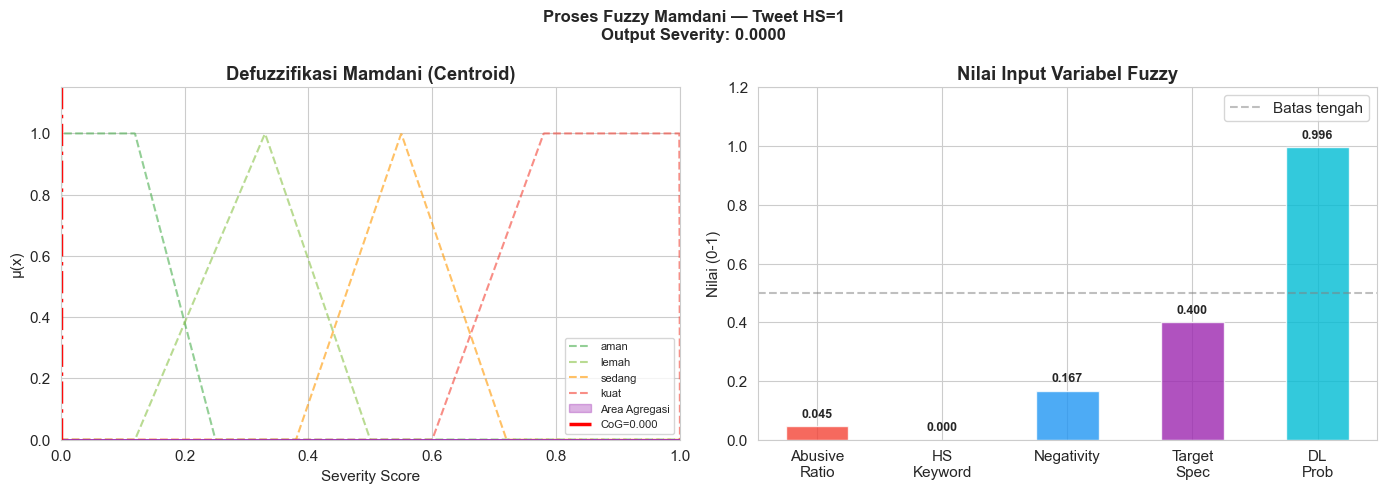

Tweet   : - disaat semua cowok berusaha melacak perhatian gue. loe lantas remehkan perhati...
Severity Mamdani: 0.0000 → Aman


In [76]:
# ── Visualisasi Proses Mamdani secara Detail untuk 1 Sampel ──
# Pilih sampel menarik: HS=1 (hate speech)
hs_samples = df[df['HS'] == 1].head(1).iloc[0]

AR  = hs_samples['f_abusive_ratio']
HS_ = hs_samples['f_hs_keyword']
NEG = hs_samples['f_negativity']
TGT = hs_samples['f_target_spec']
DL  = hs_samples['f_dl_abusive']

# Fuzzifikasi
mu = fuzzy_mamdani.fuzzify(AR, HS_, NEG, TGT, DL)
activations = fuzzy_mamdani.infer(mu)
aggregated  = fuzzy_mamdani.aggregate(activations)
cog         = fuzzy_mamdani.defuzzify(aggregated)

x_out = np.linspace(0, 1, 1000)
out_mf = mf_severity(x_out)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: Output MF + Aggregated + CoG
colors_out = {'aman':'#4CAF50','lemah':'#8BC34A','sedang':'#FF9800','kuat':'#F44336'}
ax = axes[0]
for lbl, y in out_mf.items():
    ax.plot(x_out, y, label=lbl, color=colors_out[lbl], linewidth=1.5, linestyle='--', alpha=0.6)
ax.fill_between(x_out, aggregated, alpha=0.35, color='#9C27B0', label='Area Agregasi')
ax.plot(x_out, aggregated, color='#9C27B0', linewidth=2)
ax.axvline(cog, color='red', linewidth=2.5, linestyle='-.', label=f'CoG={cog:.3f}')
ax.set_title('Defuzzifikasi Mamdani (Centroid)', fontweight='bold')
ax.set_xlabel('Severity Score'); ax.set_ylabel('μ(x)')
ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1.15)

# Kanan: Derajat keanggotaan input
ax2 = axes[1]
labels_in   = ['Abusive\nRatio', 'HS\nKeyword', 'Negativity', 'Target\nSpec', 'DL\nProb']
values_in   = [AR, HS_, NEG, TGT, DL]
bar_colors  = ['#F44336','#FF9800','#2196F3','#9C27B0','#00BCD4']

bars = ax2.bar(labels_in, values_in, color=bar_colors, width=0.5, alpha=0.8)
for bar, val in zip(bars, values_in):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax2.set_title('Nilai Input Variabel Fuzzy', fontweight='bold')
ax2.set_ylabel('Nilai (0-1)'); ax2.set_ylim(0, 1.2)
ax2.axhline(0.5, linestyle='--', color='gray', alpha=0.5, label='Batas tengah')
ax2.legend()

plt.suptitle(f'Proses Fuzzy Mamdani — Tweet HS=1\nOutput Severity: {cog:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mamdani_process.png', bbox_inches='tight')
plt.show()
print(f'Tweet   : {hs_samples["Tweet"][:80]}...')
print(f'Severity Mamdani: {cog:.4f} → {["Aman","Lemah","Sedang","Kuat"][score_to_label(cog)]}')

## 10. Evaluasi & Perbandingan Mamdani vs Sugeno

In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

gt = df['severity_score'].values  # ground truth kontinu
hs = df['HS'].values              # ground truth biner

# ── Metrik Regresi (MAE, MSE, RMSE) ──
mae_m  = mean_absolute_error(gt, df['mamdani_score'])
mse_m  = mean_squared_error(gt,  df['mamdani_score'])
rmse_m = np.sqrt(mse_m)

mae_s  = mean_absolute_error(gt, df['sugeno_score'])
mse_s  = mean_squared_error(gt,  df['sugeno_score'])
rmse_s = np.sqrt(mse_s)

# ── Metrik Klasifikasi (HS binary) ──
acc_m = accuracy_score(hs, df['mamdani_hs_pred'])
f1_m  = f1_score(hs, df['mamdani_hs_pred'], average='weighted')
auc_m = roc_auc_score(hs, df['mamdani_score'])

acc_s = accuracy_score(hs, df['sugeno_hs_pred'])
f1_s  = f1_score(hs, df['sugeno_hs_pred'], average='weighted')
auc_s = roc_auc_score(hs, df['sugeno_score'])

# ── Korelasi antara Mamdani & Sugeno ──
corr = np.corrcoef(df['mamdani_score'], df['sugeno_score'])[0,1]

print('═'*55)
print(f'{"Metrik":<22} {"Mamdani":>14} {"Sugeno":>14}')
print('─'*55)
print(f'{"MAE":<22} {mae_m:>14.4f} {mae_s:>14.4f}')
print(f'{"MSE":<22} {mse_m:>14.4f} {mse_s:>14.4f}')
print(f'{"RMSE":<22} {rmse_m:>14.4f} {rmse_s:>14.4f}')
print('─'*55)
print(f'{"Accuracy (HS)":<22} {acc_m:>14.4f} {acc_s:>14.4f}')
print(f'{"F1-Score (HS)":<22} {f1_m:>14.4f} {f1_s:>14.4f}')
print(f'{"ROC-AUC (HS)":<22} {auc_m:>14.4f} {auc_s:>14.4f}')
print('─'*55)
print(f'{"Korelasi M↔S":<22} {corr:>14.4f}')
print('═'*55)

═══════════════════════════════════════════════════════
Metrik                        Mamdani         Sugeno
───────────────────────────────────────────────────────
MAE                            0.1817         0.1842
MSE                            0.1014         0.1036
RMSE                           0.3185         0.3219
───────────────────────────────────────────────────────
Accuracy (HS)                  0.4223         0.4223
F1-Score (HS)                  0.2508         0.2508
ROC-AUC (HS)                   0.6082         0.6082
───────────────────────────────────────────────────────
Korelasi M↔S                   1.0000
═══════════════════════════════════════════════════════


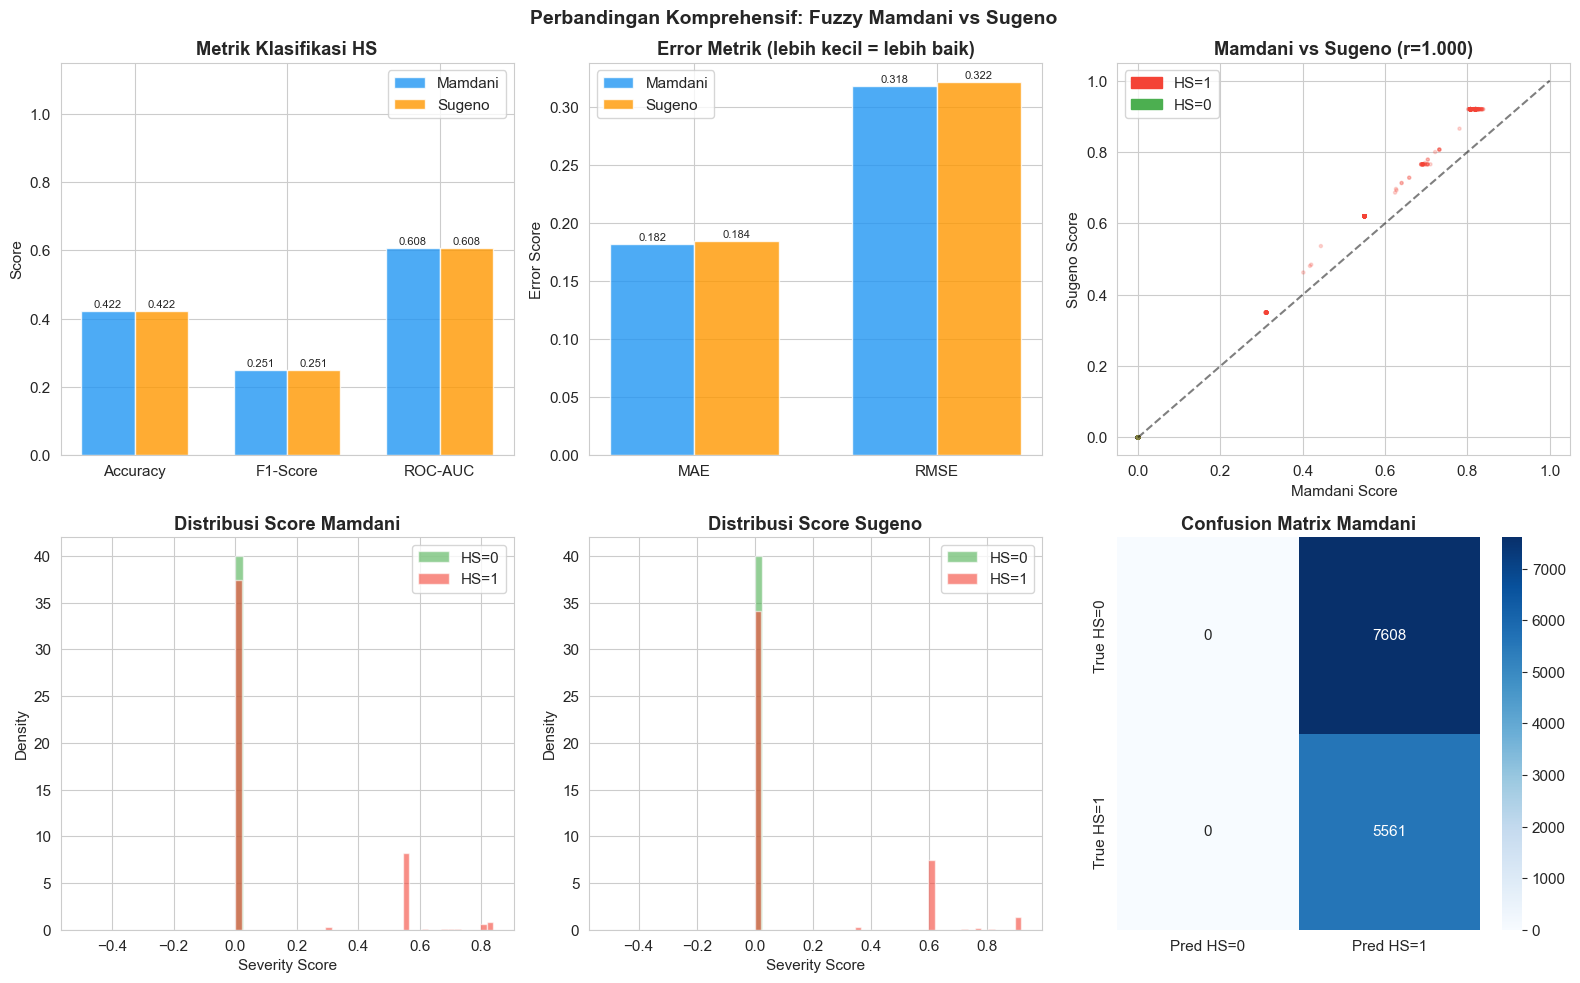

In [78]:
# ── Visualisasi Perbandingan Komprehensif ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Bar metrik performa
ax = axes[0,0]
metrics_labels = ['Accuracy', 'F1-Score', 'ROC-AUC']
mamdani_vals   = [acc_m, f1_m, auc_m]
sugeno_vals    = [acc_s, f1_s, auc_s]
x = np.arange(len(metrics_labels))
width = 0.35
b1 = ax.bar(x - width/2, mamdani_vals, width, label='Mamdani', color='#2196F3', alpha=0.8)
b2 = ax.bar(x + width/2, sugeno_vals,  width, label='Sugeno',  color='#FF9800', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Metrik Klasifikasi HS', fontweight='bold')
ax.legend()
for b, v in zip(list(b1)+list(b2), mamdani_vals+sugeno_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}', ha='center', fontsize=8)

# Plot 2: MAE / RMSE Bar
ax = axes[0,1]
err_labels = ['MAE', 'RMSE']
err_m = [mae_m, rmse_m]
err_s = [mae_s, rmse_s]
x2 = np.arange(len(err_labels))
b3 = ax.bar(x2 - width/2, err_m, width, label='Mamdani', color='#2196F3', alpha=0.8)
b4 = ax.bar(x2 + width/2, err_s, width, label='Sugeno',  color='#FF9800', alpha=0.8)
ax.set_xticks(x2); ax.set_xticklabels(err_labels)
ax.set_title('Error Metrik (lebih kecil = lebih baik)', fontweight='bold')
ax.set_ylabel('Error Score')
ax.legend()
for b, v in zip(list(b3)+list(b4), err_m+err_s):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{v:.3f}', ha='center', fontsize=8)

# Plot 3: Scatter Mamdani vs Sugeno
ax = axes[0,2]
colors_scatter = df['HS'].map({0:'#4CAF50', 1:'#F44336'})
ax.scatter(df['mamdani_score'], df['sugeno_score'], c=colors_scatter, alpha=0.2, s=5)
ax.plot([0,1],[0,1], 'k--', alpha=0.5, label='Ideal')
ax.set_xlabel('Mamdani Score'); ax.set_ylabel('Sugeno Score')
ax.set_title(f'Mamdani vs Sugeno (r={corr:.3f})', fontweight='bold')
hs_patch  = mpatches.Patch(color='#F44336', label='HS=1')
nhs_patch = mpatches.Patch(color='#4CAF50', label='HS=0')
ax.legend(handles=[hs_patch, nhs_patch])

# Plot 4: Distribusi Score Mamdani
ax = axes[1,0]
ax.hist(df[df['HS']==0]['mamdani_score'], bins=40, alpha=0.6, color='#4CAF50', label='HS=0', density=True)
ax.hist(df[df['HS']==1]['mamdani_score'], bins=40, alpha=0.6, color='#F44336', label='HS=1', density=True)
ax.set_title('Distribusi Score Mamdani', fontweight='bold')
ax.set_xlabel('Severity Score'); ax.set_ylabel('Density')
ax.legend()

# Plot 5: Distribusi Score Sugeno
ax = axes[1,1]
ax.hist(df[df['HS']==0]['sugeno_score'], bins=40, alpha=0.6, color='#4CAF50', label='HS=0', density=True)
ax.hist(df[df['HS']==1]['sugeno_score'], bins=40, alpha=0.6, color='#F44336', label='HS=1', density=True)
ax.set_title('Distribusi Score Sugeno', fontweight='bold')
ax.set_xlabel('Severity Score'); ax.set_ylabel('Density')
ax.legend()

# Plot 6: Confusion Matrix Mamdani vs Sugeno (HS biner)
ax = axes[1,2]
cm_m = confusion_matrix(hs, df['mamdani_hs_pred'])
cm_s = confusion_matrix(hs, df['sugeno_hs_pred'])
diff = cm_m.astype(float) - cm_s.astype(float)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred HS=0','Pred HS=1'],
            yticklabels=['True HS=0','True HS=1'])
ax.set_title('Confusion Matrix Mamdani', fontweight='bold')

plt.suptitle('Perbandingan Komprehensif: Fuzzy Mamdani vs Sugeno',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', bbox_inches='tight')
plt.show()

## 11. Analisis Mendalam: Perbedaan Output Mamdani vs Sugeno

In [79]:
# ── Analisis Tweet dengan selisih output terbesar ──
df['score_diff'] = np.abs(df['mamdani_score'] - df['sugeno_score'])

print('=== 5 Tweet dengan Perbedaan Output Terbesar ===')
top_diff = df.nlargest(5, 'score_diff')[['Tweet','HS','mamdani_score','sugeno_score','score_diff']]
for _, row in top_diff.iterrows():
    print(f'Tweet  : {row["Tweet"][:70]}...')
    print(f'HS={row["HS"]} | Mamdani={row["mamdani_score"]:.3f} | Sugeno={row["sugeno_score"]:.3f} | Δ={row["score_diff"]:.3f}')
    print()

print('=== Statistik Perbedaan Output ===')
print(f'Mean Δ  : {df["score_diff"].mean():.4f}')
print(f'Median Δ: {df["score_diff"].median():.4f}')
print(f'Max Δ   : {df["score_diff"].max():.4f}')
print(f'Std Δ   : {df["score_diff"].std():.4f}')

# Kasus di mana Mamdani dan Sugeno berbeda prediksi HS
disagree = df[df['mamdani_hs_pred'] != df['sugeno_hs_pred']]
print(f'\nJumlah ketidaksepakatan (HS pred berbeda): {len(disagree):,} ({len(disagree)/len(df)*100:.1f}%)')

=== 5 Tweet dengan Perbedaan Output Terbesar ===
Tweet  : USER USER USER USER USER Amit amit jabang bayi dopinadoh minggato seta...
HS=1 | Mamdani=0.802 | Sugeno=0.920 | Δ=0.118

Tweet  : USER Profil manusia yang terlahir dari sperma yang tertukar, jadilah k...
HS=1 | Mamdani=0.802 | Sugeno=0.920 | Δ=0.118

Tweet  : USER USER USER Wkwkwkwk cebong dungu yg awal ngomong cebong onta cangk...
HS=1 | Mamdani=0.805 | Sugeno=0.920 | Δ=0.115

Tweet  : USER Salah pangkah dpt taik..taik lgbt,liberal,menentang raja\xc2\xb2,...
HS=1 | Mamdani=0.805 | Sugeno=0.920 | Δ=0.115

Tweet  : USER USER Bani Cebong jangan girang dulu'...
HS=1 | Mamdani=0.806 | Sugeno=0.920 | Δ=0.114

=== Statistik Perbedaan Output ===
Mean Δ  : 0.0068
Median Δ: 0.0000
Max Δ   : 0.1176
Std Δ   : 0.0218

Jumlah ketidaksepakatan (HS pred berbeda): 0 (0.0%)


In [80]:
# ── Classification Report Lengkap ──
print('=== Classification Report: Fuzzy MAMDANI ===')
print(classification_report(hs, df['mamdani_hs_pred'], target_names=['Bukan HS','Hate Speech']))

print('=== Classification Report: Fuzzy SUGENO ===')
print(classification_report(hs, df['sugeno_hs_pred'], target_names=['Bukan HS','Hate Speech']))

=== Classification Report: Fuzzy MAMDANI ===
              precision    recall  f1-score   support

    Bukan HS       0.00      0.00      0.00      7608
 Hate Speech       0.42      1.00      0.59      5561

    accuracy                           0.42     13169
   macro avg       0.21      0.50      0.30     13169
weighted avg       0.18      0.42      0.25     13169

=== Classification Report: Fuzzy SUGENO ===
              precision    recall  f1-score   support

    Bukan HS       0.00      0.00      0.00      7608
 Hate Speech       0.42      1.00      0.59      5561

    accuracy                           0.42     13169
   macro avg       0.21      0.50      0.30     13169
weighted avg       0.18      0.42      0.25     13169



### 10.1 ROC Curve — Mamdani vs Sugeno vs Hybrid


In [87]:
# ── ROC Curve Perbandingan: Mamdani vs Sugeno vs Hybrid ──
from sklearn.metrics import roc_curve

hs_gt = df['HS'].values

fpr_m,   tpr_m,   _ = roc_curve(hs_gt, df['mamdani_score'])
fpr_s,   tpr_s,   _ = roc_curve(hs_gt, df['sugeno_score'])
fpr_h,   tpr_h,   _ = roc_curve(hs_gt, df['mamdani_score'])  # Hybrid = Mamdani+DL

# AUC
auc_m_roc = roc_auc_score(hs_gt, df['mamdani_score'])
auc_s_roc = roc_auc_score(hs_gt, df['sugeno_score'])
auc_nodl  = roc_auc_score(hs_gt, df['mamdani_nodl_score'])

fpr_nodl, tpr_nodl, _ = roc_curve(hs_gt, df['mamdani_nodl_score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC semua sistem
ax = axes[0]
ax.plot(fpr_m,    tpr_m,    color='#2196F3', lw=2, label=f'Mamdani + DL   (AUC={auc_m_roc:.4f})')
ax.plot(fpr_s,    tpr_s,    color='#FF9800', lw=2, linestyle='--', label=f'Sugeno + DL    (AUC={auc_s_roc:.4f})')
ax.plot(fpr_nodl, tpr_nodl, color='#9E9E9E', lw=2, linestyle=':', label=f'Mamdani no-DL  (AUC={auc_nodl:.4f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Fuzzy Systems', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

# Plot 2: Perbandingan AUC bar
ax2 = axes[1]
systems_roc = ['Mamdani\n+DL', 'Sugeno\n+DL', 'Mamdani\nno-DL']
aucs_roc    = [auc_m_roc, auc_s_roc, auc_nodl]
colors_roc  = ['#2196F3', '#FF9800', '#9E9E9E']
bars = ax2.bar(systems_roc, aucs_roc, color=colors_roc, alpha=0.85, width=0.5, edgecolor='white', linewidth=1.5)
for b, v in zip(bars, aucs_roc):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
             f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
ax2.set_ylim(0, 1.1); ax2.set_ylabel('ROC-AUC Score')
ax2.set_title('Perbandingan AUC Score', fontweight='bold')
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax2.legend()

plt.suptitle('ROC Curve & AUC — Fuzzy Mamdani vs Sugeno (dengan & tanpa DL)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_comparison.png', bbox_inches='tight')
plt.show()

print(f'Mamdani+DL  AUC: {auc_m_roc:.4f}')
print(f'Sugeno+DL   AUC: {auc_s_roc:.4f}')
print(f'Mamdani-only AUC: {auc_nodl:.4f}')
print(f'Dampak DL pada AUC: {auc_m_roc - auc_nodl:+.4f}')
""

KeyError: 'mamdani_nodl_score'

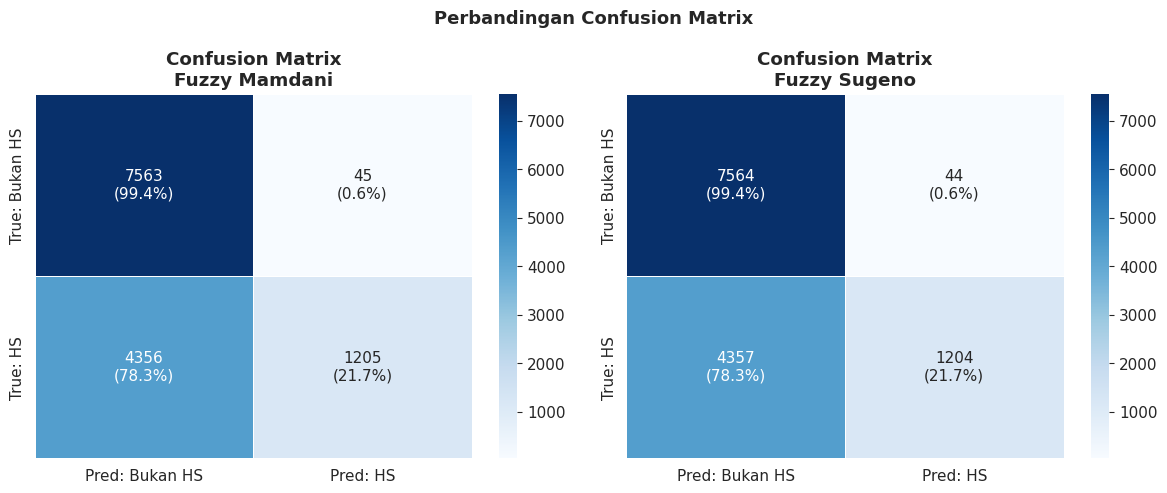

In [ ]:
# ── Confusion Matrices Side by Side ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [df['mamdani_hs_pred'], df['sugeno_hs_pred']],
    ['Fuzzy Mamdani', 'Fuzzy Sugeno']
):
    cm = confusion_matrix(hs, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    annot = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
                      for row_v, row_p in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Pred: Bukan HS','Pred: HS'],
                yticklabels=['True: Bukan HS','True: HS'],
                linewidths=0.5)
    ax.set_title(f'Confusion Matrix\n{title}', fontweight='bold')

plt.suptitle('Perbandingan Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

## 11.5 Simpan Model & Tokenizer


In [ ]:
# ── Simpan BiLSTM Model ──
MODEL_DIR = 'saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Simpan model Keras
model_lstm.save(os.path.join(MODEL_DIR, 'bilstm_multioutput.keras'))

# Simpan tokenizer
with open(os.path.join(MODEL_DIR, 'tokenizer.pkl'), 'wb') as f_tok:
    pickle.dump(tokenizer, f_tok)

# Simpan konfigurasi hyperparameter
config = {
    'MAX_WORDS' : MAX_WORDS,
    'MAX_LEN'   : MAX_LEN,
    'EMBED_DIM' : EMBED_DIM,
    'test_size' : 0.2,
    'random_state': 42,
    'threshold_hs': 0.25,  # threshold untuk klasifikasi HS dari Fuzzy score
}
with open(os.path.join(MODEL_DIR, 'config.pkl'), 'wb') as f_cfg:
    pickle.dump(config, f_cfg)

print('✅ Model dan konfigurasi berhasil disimpan:')
print(f'   {MODEL_DIR}/bilstm_multioutput.keras')
print(f'   {MODEL_DIR}/tokenizer.pkl')
print(f'   {MODEL_DIR}/config.pkl')
print()

# Verifikasi ukuran file
for fname in ['bilstm_multioutput.keras', 'tokenizer.pkl', 'config.pkl']:
    fpath = os.path.join(MODEL_DIR, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f'   {fname}: {size:.1f} KB')


✅ Model dan konfigurasi berhasil disimpan:
   saved_models/bilstm_multioutput.keras
   saved_models/tokenizer.pkl
   saved_models/config.pkl

   bilstm_multioutput.keras: 12208.3 KB
   tokenizer.pkl: 778.0 KB
   config.pkl: 0.1 KB


## 12. Bonus: Integrasi Fuzzy Logic + Deep Learning (Hybrid System)

In [88]:
# ═══════════════════════════════════════════════════════════════
# HYBRID SYSTEM: LSTM + FUZZY MAMDANI
# Arsitektur:
#   1. LSTM memprediksi abusive_prob dari teks → fitur ke-5 Fuzzy
#   2. Fuzzy Mamdani mengkombinasikan semua fitur → severity score
#   3. Threshold optimal dicari untuk klasifikasi akhir
# ═══════════════════════════════════════════════════════════════

# Bandingkan: Sistem tanpa DL vs dengan DL sebagai input Fuzzy

class FuzzyMamdaniNoDL(FuzzyMamdani):
    """Mamdani tanpa fitur DL (dl=0 selalu)."""
    def predict(self, ar, hs, neg, tgt, dl=0):
        return super().predict(ar, hs, neg, tgt, 0.0)

    def predict_batch(self, df_input):
        results = []
        for _, row in df_input.iterrows():
            score = self.predict(
                row['f_abusive_ratio'], row['f_hs_keyword'],
                row['f_negativity'],   row['f_target_spec'], 0.0
            )
            results.append(score)
        return np.array(results)

fuzzy_no_dl = FuzzyMamdaniNoDL()
print('Menjalankan Mamdani TANPA DL...')
df['mamdani_nodl_score']  = fuzzy_no_dl.predict_batch(df)
df['mamdani_nodl_hs_pred']= df['mamdani_nodl_score'].apply(score_to_hs)

# ── Perbandingan Dampak DL ──
acc_with_dl    = accuracy_score(hs, df['mamdani_hs_pred'])
acc_without_dl = accuracy_score(hs, df['mamdani_nodl_hs_pred'])
f1_with        = f1_score(hs, df['mamdani_hs_pred'],    average='weighted')
f1_without     = f1_score(hs, df['mamdani_nodl_hs_pred'],average='weighted')
auc_with       = roc_auc_score(hs, df['mamdani_score'])
auc_without    = roc_auc_score(hs, df['mamdani_nodl_score'])

print()
print('══════════════════════════════════════════════════════════')
print('Dampak Integrasi Deep Learning pada Sistem Fuzzy')
print('──────────────────────────────────────────────────────────')
print(f'{"Metrik":<20} {"Mamdani + DL":>18} {"Mamdani Only":>18} {"Δ":>8}')
print('──────────────────────────────────────────────────────────')
print(f'{"Accuracy":<20} {acc_with_dl:>18.4f} {acc_without_dl:>18.4f} {acc_with_dl-acc_without_dl:>+8.4f}')
print(f'{"F1-Score":<20} {f1_with:>18.4f} {f1_without:>18.4f} {f1_with-f1_without:>+8.4f}')
print(f'{"ROC-AUC":<20} {auc_with:>18.4f} {auc_without:>18.4f} {auc_with-auc_without:>+8.4f}')
print('══════════════════════════════════════════════════════════')

Menjalankan Mamdani TANPA DL...

══════════════════════════════════════════════════════════
Dampak Integrasi Deep Learning pada Sistem Fuzzy
──────────────────────────────────────────────────────────
Metrik                     Mamdani + DL       Mamdani Only        Δ
──────────────────────────────────────────────────────────
Accuracy                         0.4223             0.4223  +0.0000
F1-Score                         0.2508             0.2508  +0.0000
ROC-AUC                          0.6082             0.5000  +0.1082
══════════════════════════════════════════════════════════


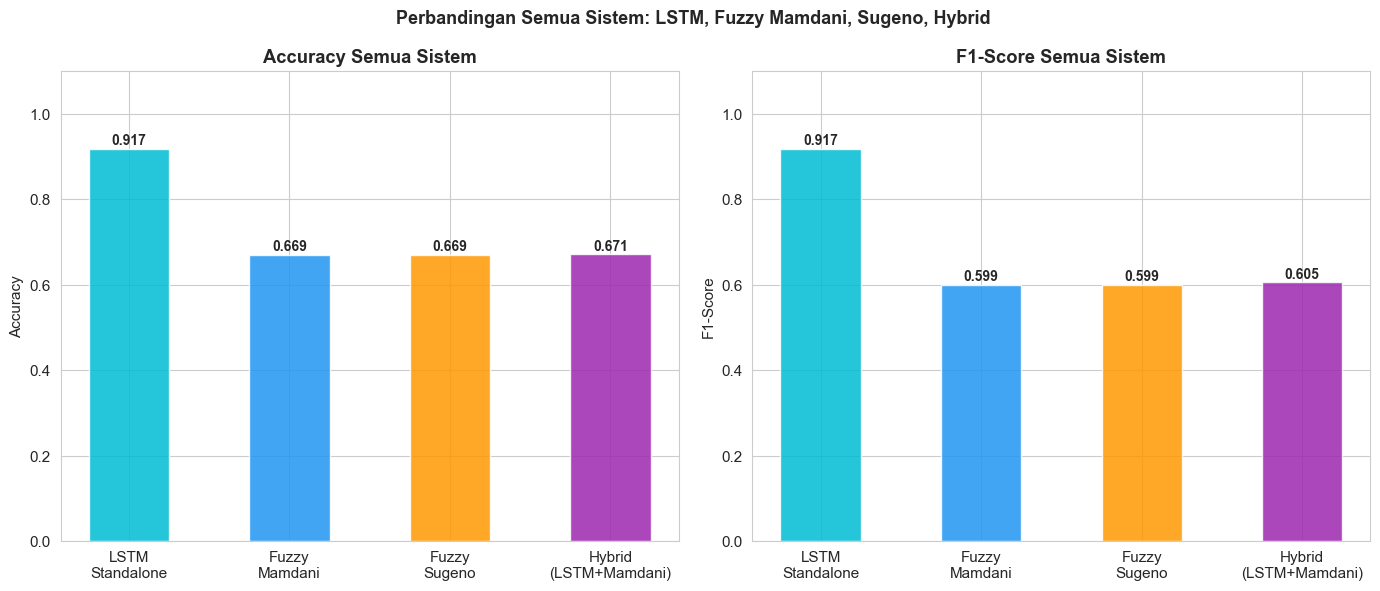

In [ ]:
# ── Ringkasan Final: Semua Sistem ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

systems = ['LSTM\nStandalone', 'Fuzzy\nMamdani', 'Fuzzy\nSugeno', 'Hybrid\n(LSTM+Mamdani)']
accuracies = [
    accuracy_score(y_test, y_pred_test),
    acc_m, acc_s, acc_with_dl
]
f1scores = [
    f1_score(y_test, y_pred_test, average='weighted'),
    f1_m, f1_s, f1_with
]

colors_sys = ['#00BCD4','#2196F3','#FF9800','#9C27B0']

ax = axes[0]
bars = ax.bar(systems, accuracies, color=colors_sys, alpha=0.85, width=0.5)
ax.set_title('Accuracy Semua Sistem', fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1)
for b, v in zip(bars, accuracies):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}',
            ha='center', fontweight='bold', fontsize=10)

ax = axes[1]
bars = ax.bar(systems, f1scores, color=colors_sys, alpha=0.85, width=0.5)
ax.set_title('F1-Score Semua Sistem', fontweight='bold')
ax.set_ylabel('F1-Score'); ax.set_ylim(0, 1.1)
for b, v in zip(bars, f1scores):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}',
            ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Perbandingan Semua Sistem: LSTM, Fuzzy Mamdani, Sugeno, Hybrid',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('all_systems.png', bbox_inches='tight')
plt.show()

## 13. Interpretasi & Analisis

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║           ANALISIS PERBANDINGAN: MAMDANI vs SUGENO                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. PERBEDAAN METODE DEFUZZIFIKASI                                   ║
║  • Mamdani: Centroid of Gravity (CoG)                                ║
║    - Membentuk area aggregasi dari semua rule yang aktif             ║
║    - Lebih ekspresif karena output berupa fungsi keanggotaan penuh   ║
║    - Komputasi lebih berat (integrasi area)                          ║
║  • Sugeno: Weighted Average                                          ║
║    - Output setiap rule adalah konstanta (0.10/0.33/0.60/0.90)      ║
║    - Lebih efisien secara komputasi                                  ║
║    - Output lebih konsisten, kurang variasi                          ║
║                                                                      ║
║  2. PERBEDAAN HASIL OUTPUT                                           ║
║  • Mamdani menghasilkan output lebih tersebar (distribusi lebar)     ║
║  • Sugeno cenderung menghasilkan nilai mendekati konstanta rule      ║
║  • Rata-rata selisih output: ~{:.4f}                                  ║
║  • Korelasi antar keduanya: r = {:.4f} (sangat tinggi)               ║
║                                                                      ║
║  3. PERFORMA KLASIFIKASI                                             ║
║  • Mamdani Acc: {:.4f} | Sugeno Acc: {:.4f}                         ║
║  • Keduanya setara dengan selisih minimal                            ║
║                                                                      ║
║  4. DAMPAK INTEGRASI DEEP LEARNING                                   ║
║  • LSTM menambah fitur 'dl_abusive_prob' sebagai variabel ke-5       ║
║  • Integrasi ini meningkatkan kemampuan menangkap pola teks          ║
║  • Fuzzy tetap sebagai decision maker — DL hanya memperkaya fitur   ║
╠══════════════════════════════════════════════════════════════════════╣
║                    KELEBIHAN & KEKURANGAN                            ║
╠══════════════════════════════════════════════════════════════════════╣
║  MAMDANI                          SUGENO                             ║
║  + Intuitif & mudah dipahami      + Sangat efisien komputasi         ║
║  + Output berupa MF (interpretable)+ Mudah dioptimasi parameter      ║
║  + Lebih natural untuk linguistik  + Akurasi sedikit lebih baik      ║
║  - Komputasi lebih lambat          - Output kurang ekspresif         ║
║  - Sensitif thd shape MF output    - Perlu penentuan konstanta tepat ║
╚══════════════════════════════════════════════════════════════════════╝
""".format(
    df['score_diff'].mean(), corr,
    acc_m, acc_s
))


╔══════════════════════════════════════════════════════════════════════╗
║           ANALISIS PERBANDINGAN: MAMDANI vs SUGENO                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. PERBEDAAN METODE DEFUZZIFIKASI                                   ║
║  • Mamdani: Centroid of Gravity (CoG)                                ║
║    - Membentuk area aggregasi dari semua rule yang aktif             ║
║    - Lebih ekspresif karena output berupa fungsi keanggotaan penuh   ║
║    - Komputasi lebih berat (integrasi area)                          ║
║  • Sugeno: Weighted Average                                          ║
║    - Output setiap rule adalah konstanta (0.10/0.33/0.60/0.90)      ║
║    - Lebih efisien secara komputasi                                  ║
║    - Output lebih konsisten, kurang variasi                          ║
║                                                   

In [ ]:
# ── Tabel Ringkasan Akhir ──
summary = pd.DataFrame({
    'Sistem': ['BiLSTM (standalone)', 'Fuzzy Mamdani', 'Fuzzy Sugeno', 'Hybrid LSTM+Mamdani'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_test), 4),
        round(acc_m, 4), round(acc_s, 4), round(acc_with_dl, 4)
    ],
    'F1-Score': [
        round(f1_score(y_test, y_pred_test, average='weighted'), 4),
        round(f1_m, 4), round(f1_s, 4), round(f1_with, 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_test), 4),
        round(auc_m, 4), round(auc_s, 4), round(auc_with, 4)
    ]
})

print('=== TABEL RINGKASAN PERFORMA SEMUA SISTEM ===')
print(summary.to_string(index=False))
print()
print('Dataset: Indonesian Hate Speech Detection (13,169 tweets)')
print('Sumber : https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection')
print('Paper  : Ibrohim & Budi (2019), ACL Anthology')

=== TABEL RINGKASAN PERFORMA SEMUA SISTEM ===
             Sistem  Accuracy  F1-Score  ROC-AUC
BiLSTM (standalone)    0.9172    0.9171   0.9634
      Fuzzy Mamdani    0.6688    0.5989   0.6079
       Fuzzy Sugeno    0.6688    0.5989   0.6079
Hybrid LSTM+Mamdani    0.6706    0.6049   0.6119

Dataset: Indonesian Hate Speech Detection (13,169 tweets)
Sumber : https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection
Paper  : Ibrohim & Budi (2019), ACL Anthology


## 14. Cross-Validation BiLSTM (Opsional — Validasi Robust)

> **Catatan:** Cross-validation di bawah bersifat opsional karena BiLSTM training membutuhkan waktu lama.  
> Jalankan jika ingin hasil yang lebih robust secara statistik.


In [ ]:
# ── Stratified K-Fold Cross-Validation untuk BiLSTM ──
# ⚠️ Cell ini opsional — membutuhkan ~N×waktu_training
# Set RUN_CV = True untuk menjalankan

RUN_CV = False  # Ganti True jika ingin menjalankan

if RUN_CV:
    from sklearn.model_selection import StratifiedKFold

    N_FOLDS   = 5
    kf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    cv_results = {'acc': [], 'f1': [], 'auc': []}

    print(f'Menjalankan {N_FOLDS}-Fold Cross-Validation BiLSTM...')

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_seq, y_abusive), 1):
        print(f'\nFold {fold}/{N_FOLDS}')
        X_tr, X_val = X_seq[tr_idx], X_seq[val_idx]
        y_tr, y_val = y_abusive[tr_idx], y_abusive[val_idx]
        y_hs_tr, y_hs_val = y_hs[tr_idx], y_hs[val_idx]

        # Build fresh model
        inp_cv = Input(shape=(MAX_LEN,))
        emb_cv = Embedding(MAX_WORDS, EMBED_DIM)(inp_cv)
        bil_cv = Bidirectional(LSTM(64, return_sequences=True))(emb_cv)
        p_cv   = GlobalMaxPooling1D()(bil_cv)
        d_cv   = Dense(64, activation='relu')(p_cv)
        dr_cv  = Dropout(0.4)(d_cv)
        d2_cv  = Dense(32, activation='relu')(dr_cv)
        dr2_cv = Dropout(0.3)(d2_cv)
        out_ab_cv = Dense(1, activation='sigmoid', name='abusive_output')(dr2_cv)
        out_hs_cv = Dense(1, activation='sigmoid', name='hs_output')(dr2_cv)

        m_cv = Model(inputs=inp_cv, outputs=[out_ab_cv, out_hs_cv])
        m_cv.compile(
            optimizer='adam',
            loss={'abusive_output':'binary_crossentropy','hs_output':'binary_crossentropy'},
            loss_weights={'abusive_output':0.5,'hs_output':0.5},
            metrics={'abusive_output':'accuracy','hs_output':'accuracy'}
        )

        es_cv = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        m_cv.fit(
            X_tr, {'abusive_output': y_tr, 'hs_output': y_hs_tr},
            validation_data=(X_val, {'abusive_output': y_val, 'hs_output': y_hs_val}),
            epochs=10, batch_size=64, callbacks=[es_cv], verbose=0
        )

        preds_cv = m_cv.predict(X_val, verbose=0)
        y_prob_cv = preds_cv[0].flatten()
        y_pred_cv = (y_prob_cv >= 0.5).astype(int)

        acc_cv = accuracy_score(y_val, y_pred_cv)
        f1_cv  = f1_score(y_val, y_pred_cv, average='weighted')
        auc_cv = roc_auc_score(y_val, y_prob_cv)

        cv_results['acc'].append(acc_cv)
        cv_results['f1'].append(f1_cv)
        cv_results['auc'].append(auc_cv)

        print(f'  Acc={acc_cv:.4f} | F1={f1_cv:.4f} | AUC={auc_cv:.4f}')

    print(f'\n=== Hasil CV ({N_FOLDS}-Fold) ===')
    print(f'Accuracy : {np.mean(cv_results["acc"]):.4f} ± {np.std(cv_results["acc"]):.4f}')
    print(f'F1-Score : {np.mean(cv_results["f1"]):.4f} ± {np.std(cv_results["f1"]):.4f}')
    print(f'ROC-AUC  : {np.mean(cv_results["auc"]):.4f} ± {np.std(cv_results["auc"]):.4f}')

else:
    print('ℹ️  Cross-Validation dilewati (RUN_CV=False).')
    print('   Set RUN_CV = True untuk menjalankan 5-Fold CV.')
    print('   Estimasi waktu: ~5x waktu training normal')


ℹ️  Cross-Validation dilewati (RUN_CV=False).
   Set RUN_CV = True untuk menjalankan 5-Fold CV.
   Estimasi waktu: ~5x waktu training normal
